In [397]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates 
import matplotlib.ticker as ticker 
from matplotlib.axis import Axis 
import datetime as dt
from datetime import datetime, date
#plt.style.use(['science', 'notebook'])
# %matplotlib inline

import time
begin = time.time()

### Le fichier temp03062024.csv est mis à jour par weather_bis.py sur pi4 dans terminal
### A partir de 02/01/2026 10h, weather_ter.py marche en double pour créer le csv temp02012026.csv


In [398]:

#csv_file1 = r"Y:\Documents\temp16122022.csv.old"  # saved 16/12/2022

# 2024-2026
csv_file1 = r"Y:\Documents\temp03062024.csv"

# 2026
#csv_file1 = r"Y:\Documents\temp02012026.csv"

#csv_file2 = r"Z:\Documents\temp16122022.csv"


In [399]:

def read_text(filename):
    f = open(filename, "r")
    text = f.readlines()
    f.close()
    print(text)


def get_data(filename):    
    data = pd.read_csv(filename)
    #data['time'] = pd.to_datetime(data['time'])  #.dt.tz_convert(None)
    #data.info()
    #print(data.tail(5))
    return data

try:
    data = get_data(csv_file1)
except:
    data = get_data(csv_file2)
#data['heure'] = pd.to_datetime(data['time']).dt.strftime('%H:%M') #time
#data['jour'] = pd.to_datetime(data['time']).dt.strftime('%d/%m') #date
len(data), data

(20158,
         temp
 0      13.19
 1      12.20
 2      12.29
 3      12.42
 4      14.54
 ...      ...
 20153  18.32
 20154  17.77
 20155  18.88
 20156  22.17
 20157  23.28
 
 [20158 rows x 1 columns])

In [400]:
def from_csv(csv_file):    
    df = pd.read_csv(csv_file)
    return df

def to_csv(csv_file, df):
    df.to_csv(csv_file, index=False)


<Axes: >

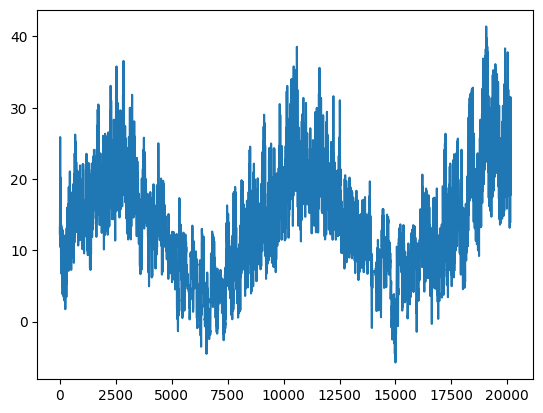

In [401]:
data['temp'].plot()

In [402]:
csv_file1

'Y:\\Documents\\temp03062024.csv'

In [403]:
# convert string to datetime

date_time_str = '16/04/24 07:00:00'   # avant 2026
# décalage car il manque des data sur 5 jours et 6 heures fin 2025
date_time_str = '21/04/24 13:00:00'   # date de début des data 2024-2026
if csv_file1 == r"Y:\Documents\temp02012026.csv":
    date_time_str = '03/01/26 08:00:00'    # début 2026
ref = datetime.strptime(date_time_str, '%d/%m/%y %H:%M:%S')

then = ref + dt.timedelta(hours=len(data))
ref,then

(datetime.datetime(2024, 4, 21, 13, 0), datetime.datetime(2026, 8, 9, 11, 0))

In [404]:
len(data), date_time_str

(20158, '21/04/24 13:00:00')

In [405]:
def mk_date(date_time_str,data):
    # 
    ref = datetime.strptime(date_time_str, '%d/%m/%y %H:%M:%S')
    then = ref + dt.timedelta(hours=len(data))
    return mdates.drange(ref,then,dt.timedelta(hours=1))


In [406]:
hours = mk_date(date_time_str,data)
#len(hours)
dates = [datetime.strftime(h, '%d/%m/%y %H:%M:%S') for h in mdates.num2date(hours)]
#dates
if len(data)<len(hours):
    data['hours']=hours[:-1]
    data['dates']=dates[:-1]
else:
    data['hours']=hours
    data['dates']=dates
data

,temp,hours,dates
0,13.19,19834.541667,21/04/24 13:00:00
1,12.20,19834.583333,21/04/24 14:00:00
2,12.29,19834.625000,21/04/24 15:00:00
3,12.42,19834.666667,21/04/24 16:00:00
4,14.54,19834.708333,21/04/24 17:00:00
...,...,...,...
20153,18.32,20674.250000,09/08/26 06:00:00
20154,17.77,20674.291667,09/08/26 07:00:00
20155,18.88,20674.333333,09/08/26 08:00:00
20156,22.17,20674.375000,09/08/26 09:00:00


In [407]:
data[['dates','temp']]

,dates,temp
0,21/04/24 13:00:00,13.19
1,21/04/24 14:00:00,12.20
2,21/04/24 15:00:00,12.29
3,21/04/24 16:00:00,12.42
4,21/04/24 17:00:00,14.54
...,...,...
20153,09/08/26 06:00:00,18.32
20154,09/08/26 07:00:00,17.77
20155,09/08/26 08:00:00,18.88
20156,09/08/26 09:00:00,22.17


In [408]:
import warnings
warnings.filterwarnings("ignore")


In [409]:
# data des 24 premieres heures
d_24 = data[:24]['temp']
#d_24


In [410]:
# moyenne des premieres 24 heures
m_day = d_24.mean()
m_day

np.float64(19.400000000000016)

In [411]:
# moyenne sur 24 heures depuis le 16/12/2022 9h
mean_all = []
window = 24
h_w = window//2
for l in range(len(data)-window):
    d_24 = data[l:l+window]['temp'].mean()
    mean_all.append(d_24)
x = data[:-window]['hours'].values    
len(mean_all), len(x)

(20134, 20134)

In [412]:
def format_date(space=3):
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))  #('%d/%m\n%H:%M'))
    #plt.gca().xaxis.set_major_locator(mdates.HourLocator(space))
    plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=space*5))
    plt.gcf().autofmt_xdate()
    plt.grid()

Text(0.5, 1.0, 'Moyenne sur 24 heures sur 7 jours')

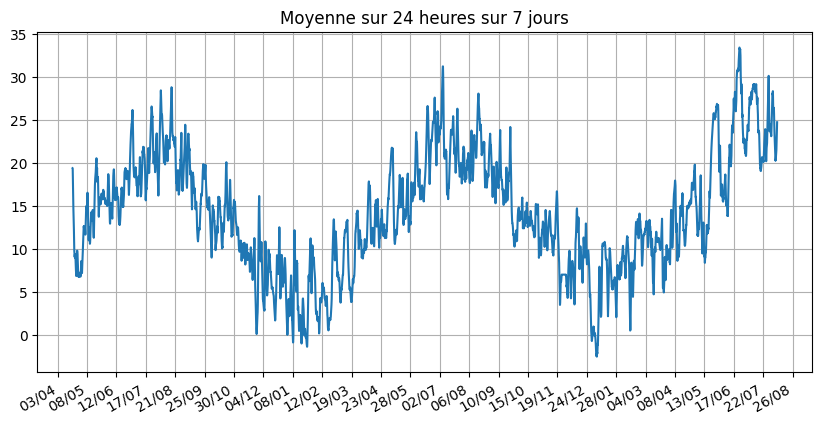

In [413]:
fig, ax = plt.subplots()
fig.set_size_inches(10, 5)
plt.plot(x,mean_all, markersize=1)
jours = 7
format_date(jours*24) # jours x 24 h
plt.title(f'Moyenne sur 24 heures sur {jours} jours') #depuis le 16/12/2022')
#plt.grid()

In [414]:
today = datetime.now()
diff = today - ref
diff

datetime.timedelta(days=839, seconds=76883, microseconds=852933)

In [415]:
days = diff.days + diff.seconds/(24*3600)
days = int(days)


In [416]:
# moyenne depuis le 16/12/22
slice = int(days*24)
h = data.tail(slice).hours
t = data.tail(slice).temp
#h, t
ref,today,days


(datetime.datetime(2024, 4, 21, 13, 0),
 datetime.datetime(2026, 8, 9, 10, 21, 23, 852933),
 839)

In [417]:
temp = data['temp']
moyenne = data['temp'].mean()
moyenne

np.float64(14.172468994939997)

np.float64(14.172468994939997)

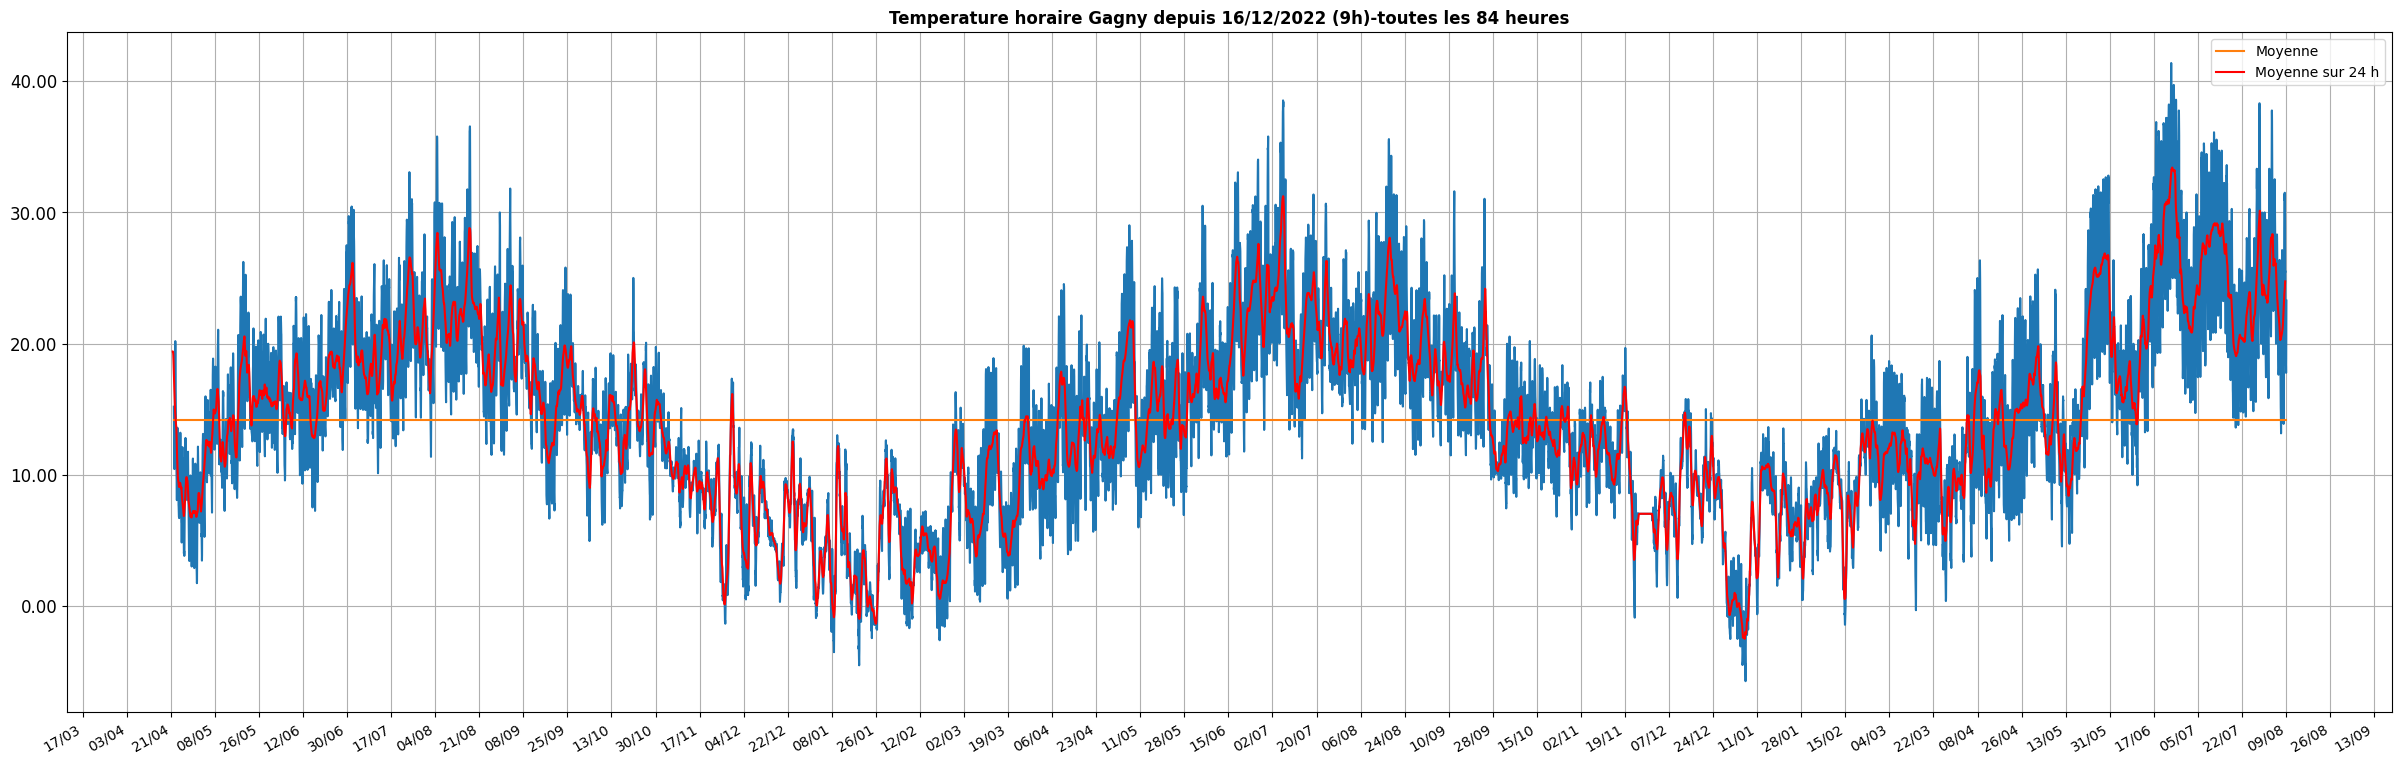

In [418]:
interval = 84
fig, ax = plt.subplots()
fig.set_size_inches(30, 10)
#plot = data['temp'].plot(figsize=(12,6))
plt.plot(h,t)
h1 = h.head(1)
h2 = h.tail(1)
plt.plot((h1,h2),(moyenne, moyenne),label='Moyenne')
plt.plot(hours[h_w:len(data)-h_w],mean_all,'r-',label=f'Moyenne sur {window} h')
#plt.plot(hours,temp)
plt.title(f"Temperature horaire Gagny depuis 16/12/2022 (9h)-toutes les {interval} heures",fontweight ='bold')


plt.legend()
#ax.set_xticks(hours)
ax.set_xticklabels(hours,fontsize=10)
#ax.set_yticks()
ax.set_yticklabels(temp,fontsize=12)

# Y_axis
formatter = ticker.FormatStrFormatter('%1.2f')
Axis.set_major_formatter(ax.yaxis, formatter)
format_date(12*7)
# plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d/%m:%H:%M'))
# plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=interval))
# plt.gcf().autofmt_xdate()
# plt.grid()
moyenne


In [419]:
data['variation']=data['temp'].diff()
data

,temp,hours,dates,variation
0,13.19,19834.541667,21/04/24 13:00:00,NaN
1,12.20,19834.583333,21/04/24 14:00:00,-0.99
2,12.29,19834.625000,21/04/24 15:00:00,0.09
3,12.42,19834.666667,21/04/24 16:00:00,0.13
4,14.54,19834.708333,21/04/24 17:00:00,2.12
...,...,...,...,...
20153,18.32,20674.250000,09/08/26 06:00:00,0.00
20154,17.77,20674.291667,09/08/26 07:00:00,-0.55
20155,18.88,20674.333333,09/08/26 08:00:00,1.11
20156,22.17,20674.375000,09/08/26 09:00:00,3.29


In [420]:
today

datetime.datetime(2026, 8, 9, 10, 21, 23, 852933)

<Axes: >

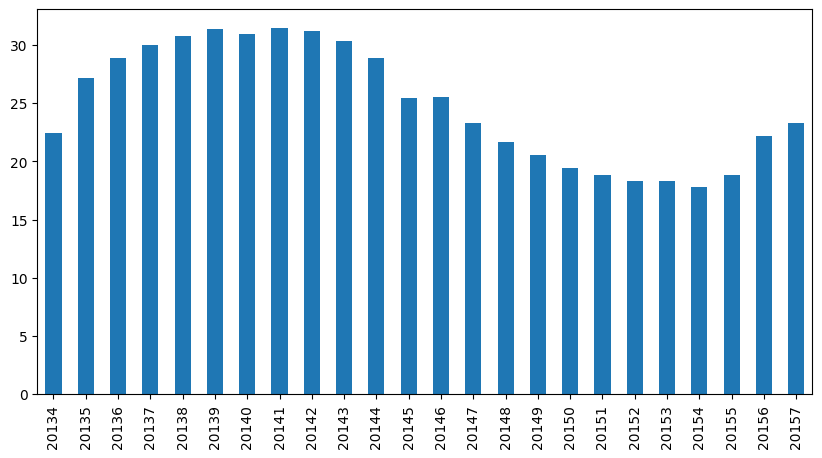

In [421]:
data.tail(24)['temp'].plot.bar(figsize=(10,5))

In [422]:
data

,temp,hours,dates,variation
0,13.19,19834.541667,21/04/24 13:00:00,NaN
1,12.20,19834.583333,21/04/24 14:00:00,-0.99
2,12.29,19834.625000,21/04/24 15:00:00,0.09
3,12.42,19834.666667,21/04/24 16:00:00,0.13
4,14.54,19834.708333,21/04/24 17:00:00,2.12
...,...,...,...,...
20153,18.32,20674.250000,09/08/26 06:00:00,0.00
20154,17.77,20674.291667,09/08/26 07:00:00,-0.55
20155,18.88,20674.333333,09/08/26 08:00:00,1.11
20156,22.17,20674.375000,09/08/26 09:00:00,3.29


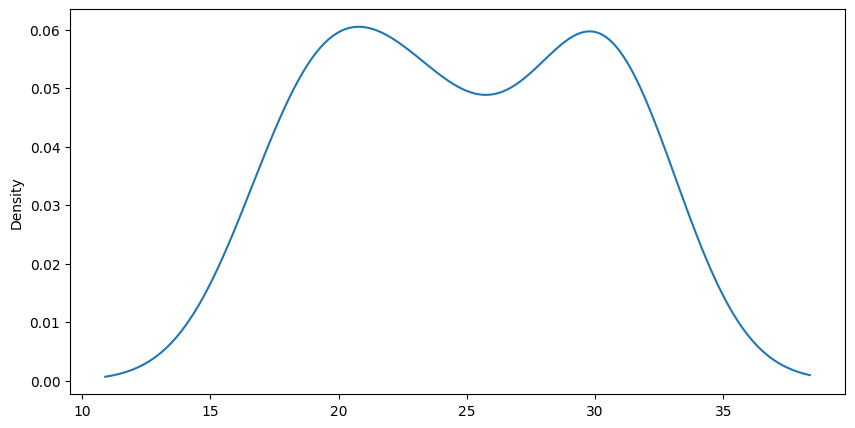

In [423]:
span = 24
try:
    data.tail(span)['temp'].plot.kde(figsize=(10,5))
    #data['temp'].plot.kde(figsize=(10,5))
except:
    pass

<Axes: ylabel='Frequency'>

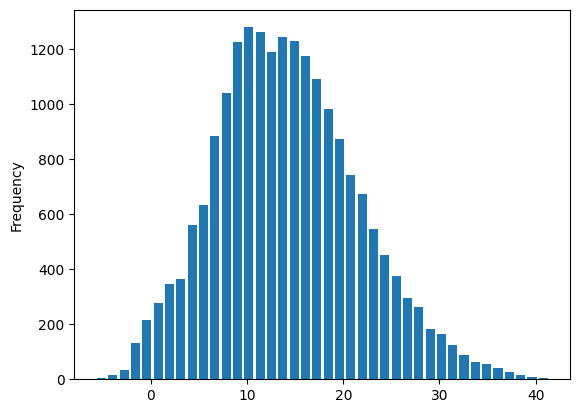

In [424]:
data['temp'].plot.hist(bins=40,rwidth=0.8) #,histtype='step')


In [425]:
#data['temp'].plot.kde(xlim=(-10,40)) #,logy=True)

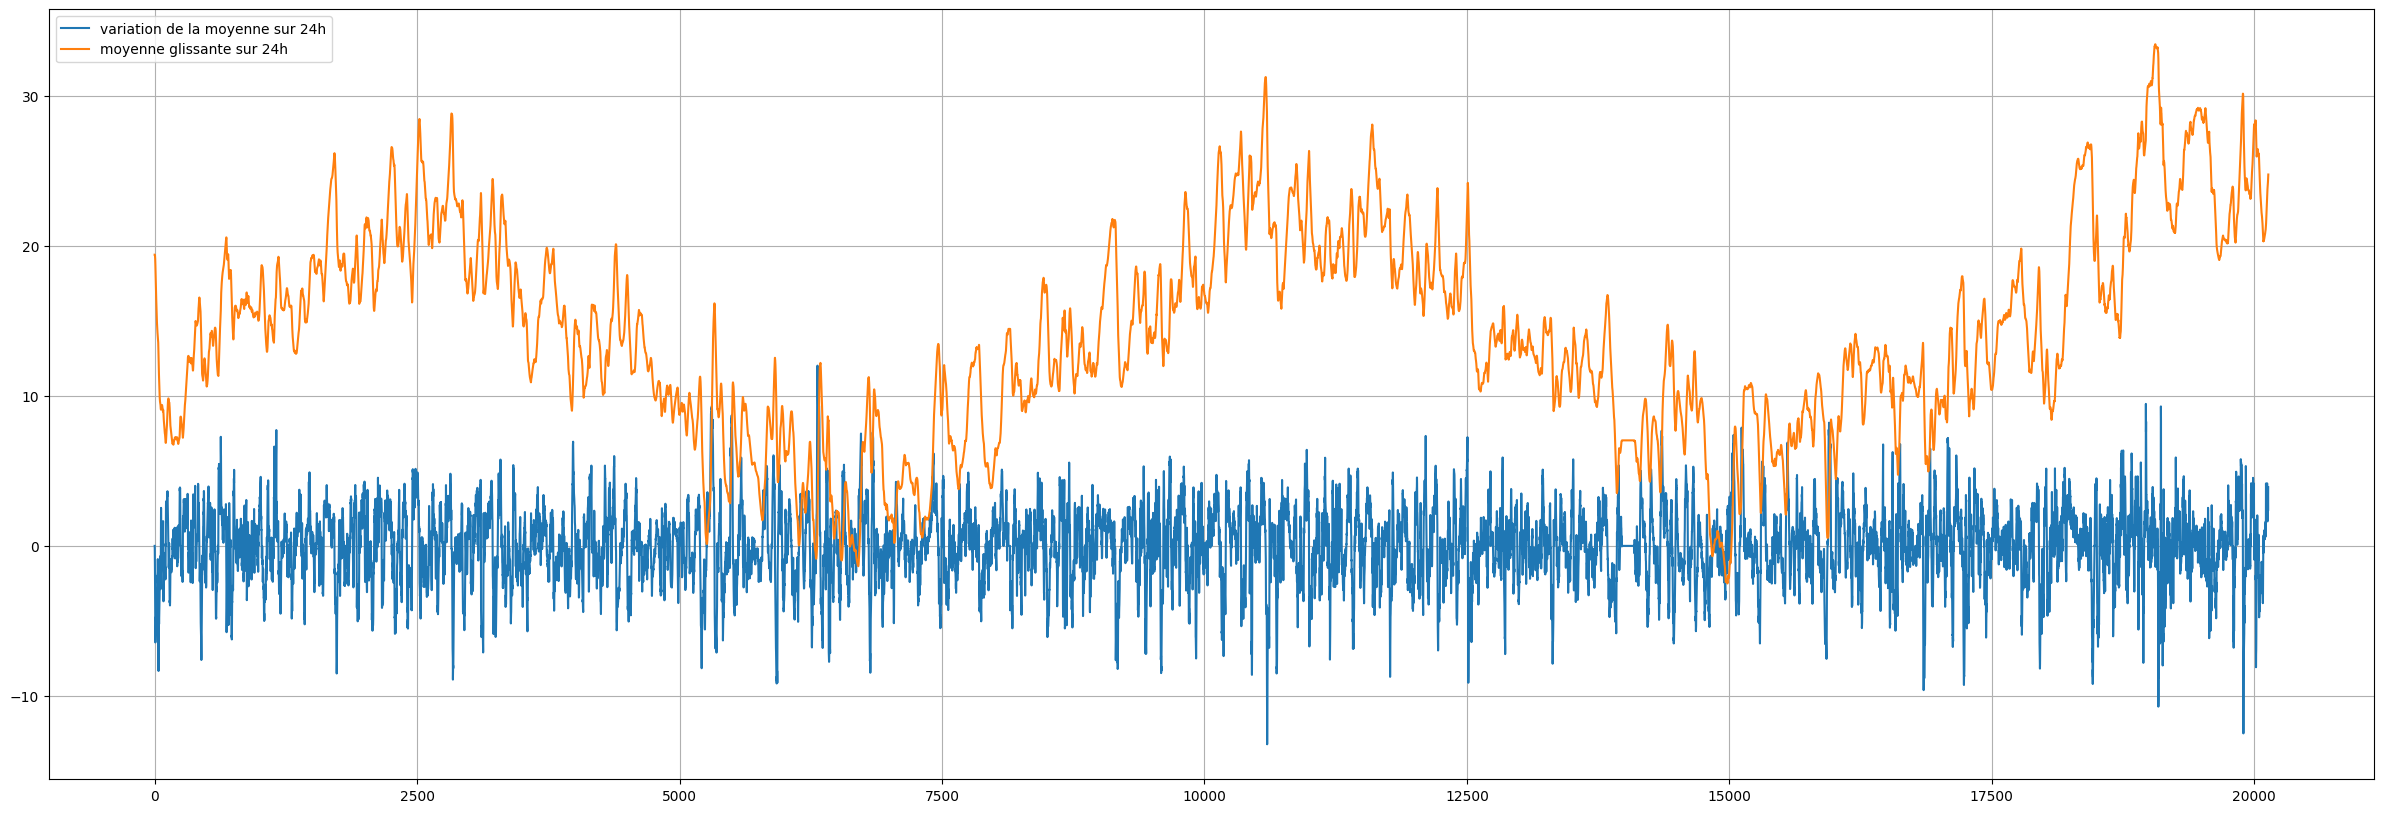

In [426]:
# variation horaire
fig, ax = plt.subplots()
fig.set_size_inches(30, 10)
delta = np.diff(mean_all)
facteur = 20   # amplifie la variation delta
plt.plot(facteur*delta,label='variation de la moyenne sur 24h')
plt.plot(mean_all,label='moyenne glissante sur 24h')
plt.legend()
plt.grid()

## Définir une fenêtre de visualisation : days

In [427]:
# fenetre de visualisation
days = 15
#days = int(len(data)/24)  # sur toute la liste de data


# xAxis interval
if days>30:
    interval = 72
elif days>15:
    interval = 24
elif days>7:
    interval = 12
else:
    interval = 6


In [428]:
window, days, interval

(24, 15, 12)

In [429]:
# moyenne avec une fenetre de 24h (window) calculé sur le nombre de jours=days 
mean_days = []
max_days = []
min_days = []
ecart_days = []

slice = int(days*24) # last days
#hours[-slice:],temp[-slice:]
h = data.tail(slice).hours
t = data.tail(slice).temp
#h.iloc[0]
start = datetime.now() - dt.timedelta(days=days)
window_start = start.strftime("%d/%m/%Y, %H:%M:%S")

#window = 24
#h_w = int(window/2)
for l in range(len(t)-window):
    d_24 = t[l:l+window].mean()
    M_24 = t[l:l+window].max()
    m_24 = t[l:l+window].min()
    mean_days.append(d_24)
    max_days.append(M_24)
    min_days.append(m_24)
    ecart_days.append(M_24-m_24)
moyenne = t.mean()
#moyenne  # moyenne sur la fenetre de visualisation
len(h[:-24]),len(max_days), len(min_days),len(ecart_days),window

(336, 336, 336, 336, 24)

In [430]:
h

19798    20659.458333
19799    20659.500000
19800    20659.541667
19801    20659.583333
19802    20659.625000
             ...     
20153    20674.250000
20154    20674.291667
20155    20674.333333
20156    20674.375000
20157    20674.416667
Name: hours, Length: 360, dtype: float64

In [431]:
datetime.now()

datetime.datetime(2026, 8, 9, 10, 21, 29, 735435)

In [432]:
window_start

'25/07/2026, 10:21:29'

In [433]:
def select(days):
    # moyenne sur la fenetre days
    mean_days = []
    max_days = []
    min_days = []
    ecart_days = []
    # fenetre de visualisation
    #days = int(len(data)/24)  # sur toute la liste de data
    #days = 30
    slice = int(days*24) # last days
    #hours[-slice:],temp[-slice:]
    h = data.tail(slice).hours
    t = data.tail(slice).temp
    #h.iloc[0]
    #start = datetime.now() - dt.timedelta(days=days)
    #window_start = start.strftime("%d/%m/%Y, %H:%M:%S")
    
    #window = 24
    #h_w = int(window/2)
    for l in range(len(t)-window):
        d_24 = t[l:l+window].mean()
        M_24 = t[l:l+window].max()
        m_24 = t[l:l+window].min()
        ecart_days.append(M_24 - m_24)
        mean_days.append(d_24)
        max_days.append(M_24)
        min_days.append(m_24)
    moyenne = t.mean()
    #moyenne  # moyenne sur la fenetre de visualisation
    return mean_days,max_days,min_days,ecart_days,moyenne


mean_d,max_d,min_d,ecart_d,moyenne = select(days)
moyenne

np.float64(24.22600000000002)

In [434]:
mean_d,max_d,min_d,ecart_d,moyenne = select(15)
len(mean_d),moyenne

(336, np.float64(24.22600000000002))

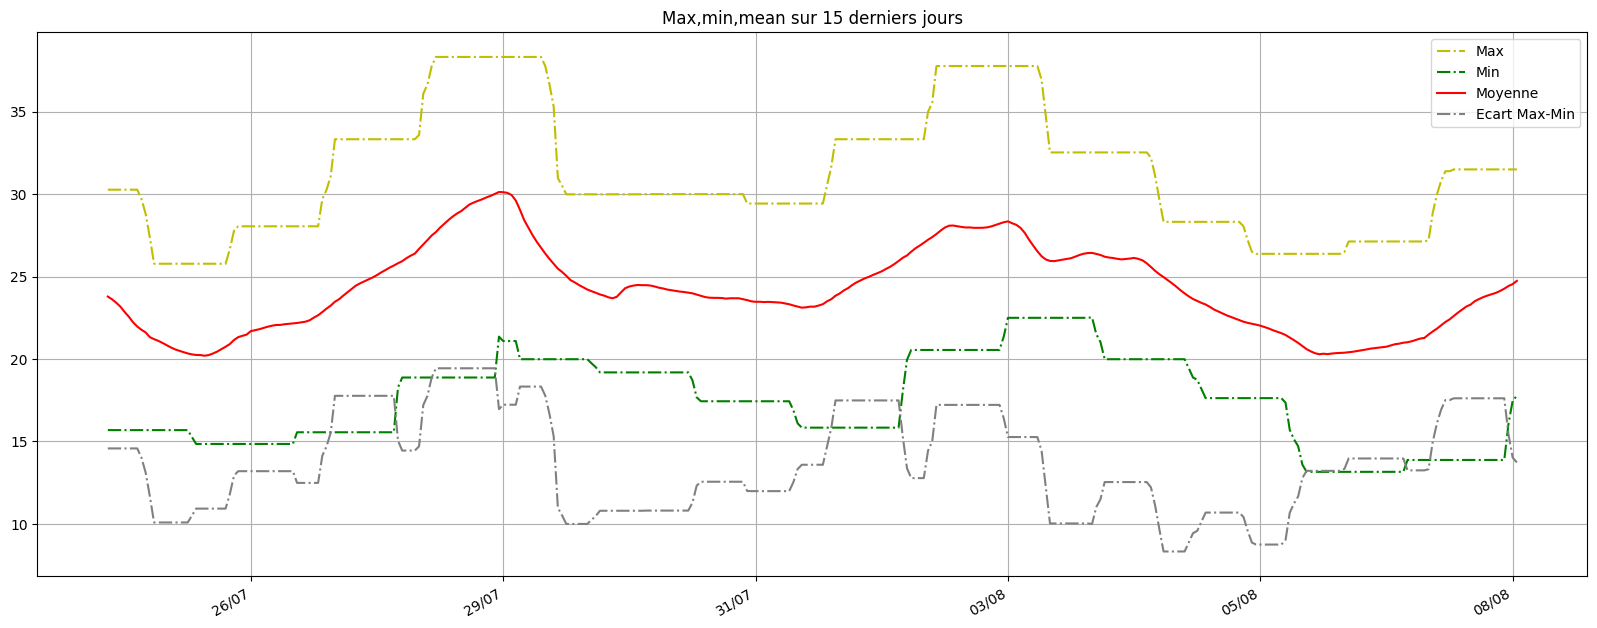

In [435]:
fig, ax = plt.subplots()
# the size of A4 paper
fig.set_size_inches(20, 8)
x = h[:-24]
plt.title(f"Max,min,mean sur {days} derniers jours")
plt.plot(x,max_days,"y-.",label="Max")
plt.plot(x,min_days,"g-.",label="Min")
plt.plot(x,mean_days,'r',label="Moyenne")
plt.plot(x,ecart_days,'-.',color='grey',label="Ecart Max-Min")
#plt.plot(t[l:l+window])
format_date(interval)
plt.legend()

In [436]:
#delta = [j-i for i, j in zip(mean_week[:-1], mean_week[1:])]
delta = np.diff(mean_days)
#delta

## Delta/days des moyennes 24h avec un glissement d'une heure

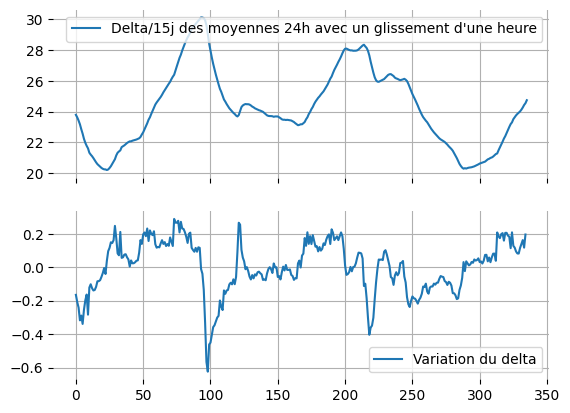

In [437]:
#fig,ax =plt.subplots(nrows=2)
#fig,ax =plt.subplots(nrows=2, sharex=True)
fig,ax =plt.subplots(nrows=2, sharex=True, subplot_kw=dict(frameon=False))
ax[0].plot(mean_days,label='Delta/'+str(days)+'j des moyennes 24h avec un glissement d\'une heure')
ax[1].plot(delta,label=('Variation du delta'))
ax[0].grid()
ax[1].grid()
ax[0].legend()
ax[1].legend()


In [438]:
def local_min_max(liste):
    """
    Trouve les minima et maxima locaux d'une liste.

    Args:
    liste: La liste à analyser.

    Returns:
    Les listes max et min.
    """

    max = []
    min = []

    if liste[0] > liste[1]:
        max.append(liste[0])
    elif liste[0] <= liste[1] :
        min.append(liste[0])

    for i in range(1, len(liste) - 1):
        if liste[i] > liste[i - 1] and liste[i] >= liste[i + 1]:
            max.append(liste[i])
        elif liste[i] <= liste[i - 1] and liste[i] < liste[i + 1]:
            min.append(liste[i])

    return max, min


liste = [10, 11, 15, 12, 9, 7, 8, 10, 13, 15, 18, 16, 12, 10, 7, 5, 6, 11, 14, 14]
max, min = local_min_max(liste)

max,min

([15, 18, 14], [10, 7, 5])

In [439]:
# graphical output...
from pylab import sign, diff # type: ignore


In [440]:
# plot graph with local max and min
def plot_data(x,data,lw=3):
    # find the indexes of maximas and the minimas
    #a = diff(sign(diff(data))).nonzero()[0] + 1 # local min+max
    b = (diff(sign(diff(data))) > 0).nonzero()[0] + 1 # local min
    c = (diff(sign(diff(data))) < 0).nonzero()[0] + 1 # local max
    print(b,len(b),c,len(c))
    # plot the curve
    plt.plot(x,data,lw=lw)
    #plot the maximas
    for v in b:
        plt.plot(x[v], data[v], "ob")
    #plot the minimas
    for v in c:
        plt.plot(x[v], data[v], "or")
    plt.grid()


[ 5 15] 2 [ 2 10 18] 3


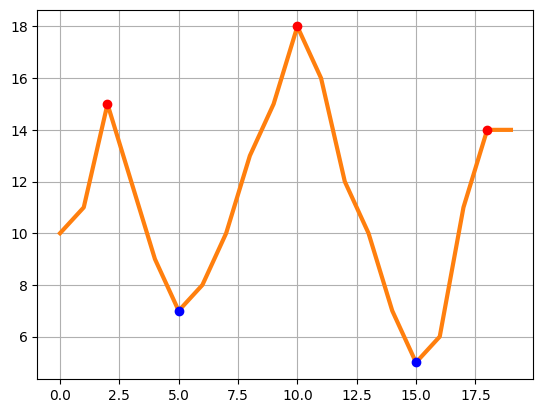

In [441]:
x = range(len(liste))
plt.plot(liste)
plot_data(x,liste)

In [442]:
jours = 7
data['heures']=[k.split(' ')[1].split(':')[0] for k in data.dates]
data['jours']=[k.split(' ')[0] for k in data.dates]

data.tail(24*jours)[['jours','heures','temp','variation']]

,jours,heures,temp,variation
19990,02/08/26,11,24.99,3.93
19991,02/08/26,12,28.04,3.05
19992,02/08/26,13,30.56,2.52
19993,02/08/26,14,31.66,1.10
19994,02/08/26,15,33.33,1.67
...,...,...,...,...
20153,09/08/26,06,18.32,0.00
20154,09/08/26,07,17.77,-0.55
20155,09/08/26,08,18.88,1.11
20156,09/08/26,09,22.17,3.29


In [443]:
_min_ = round(data.tail(24*jours).temp.min(),2)
_max_ = round(data.tail(24*jours).temp.max(),2)

In [444]:
_max_ - _min_

np.float64(24.610000000000003)

In [445]:
window_start

'25/07/2026, 10:21:29'

## Main graph

(np.float64(24.22600000000002), 15)

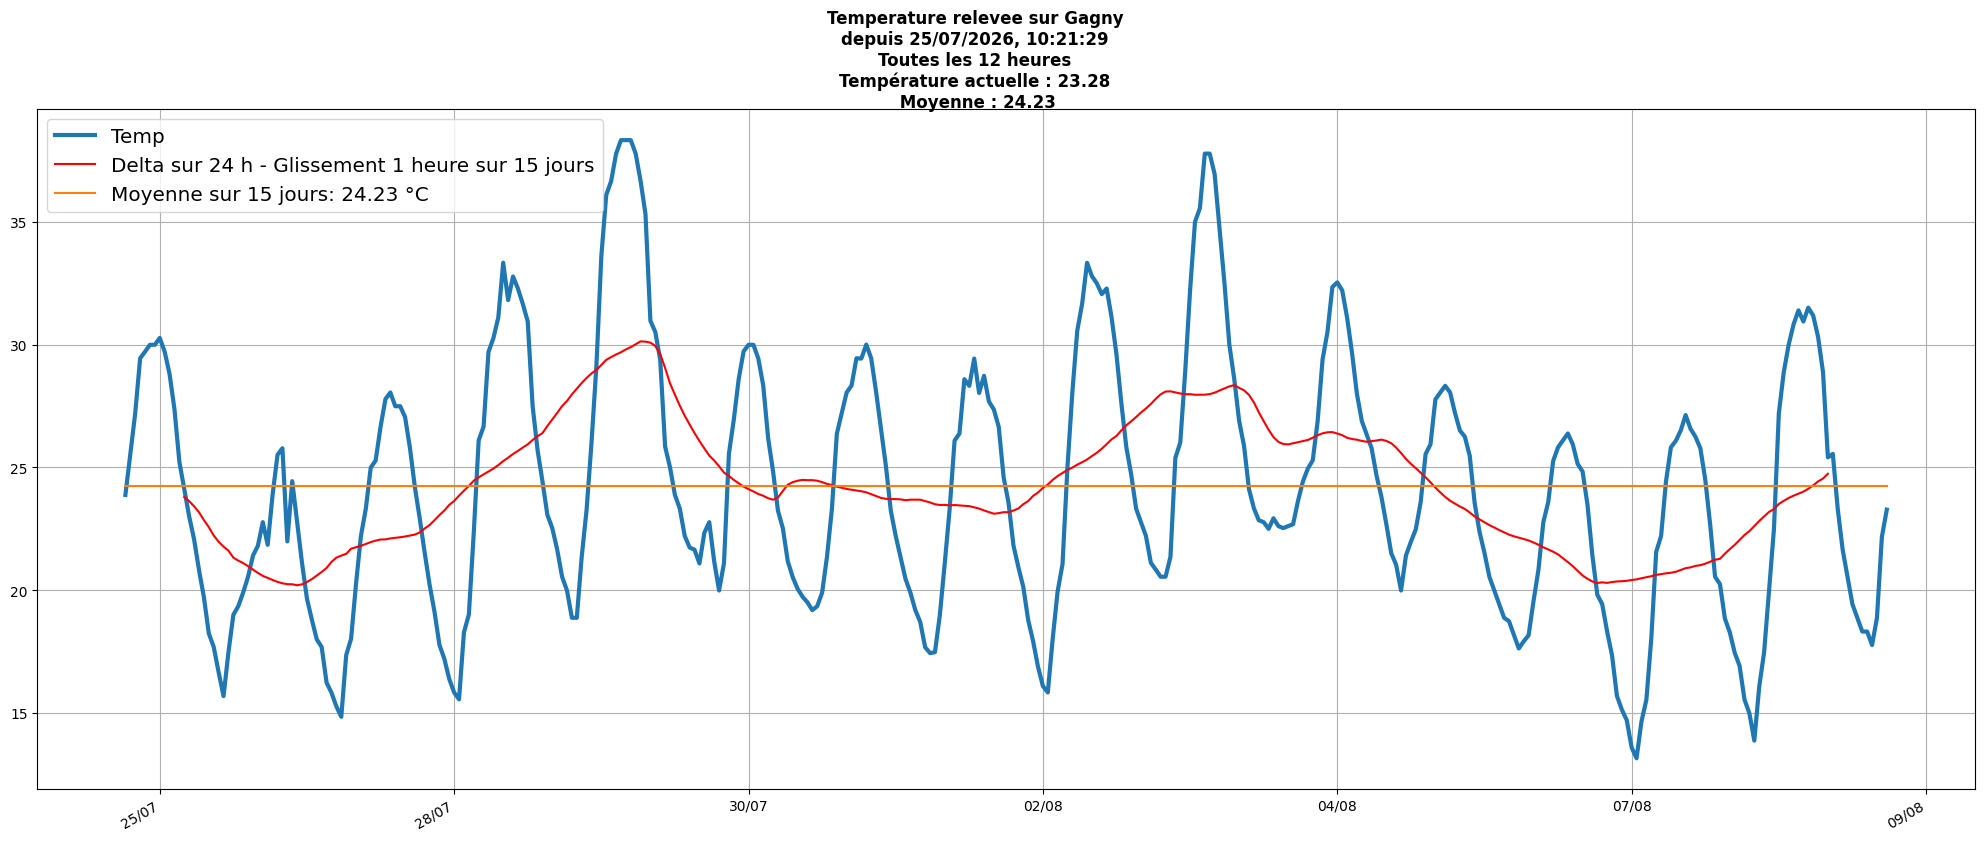

In [446]:
fig, ax = plt.subplots()
# the size of A4 paper
fig.set_size_inches(25, 10)
ax.set_xticklabels(hours,fontsize=10)
fig.suptitle(f"Temperature relevee sur Gagny\n\
depuis {window_start}\n\
Toutes les {interval} heures\nTempérature actuelle : {round(t.tail(1).values[0],2)}\n Moyenne : {round(moyenne,2)}", fontsize = 12, fontweight ='bold') 
#ax.xaxis.set_major_locator(mdates.DayLocator()) 
# plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d/%m\n%H:%M'))
# plt.gca().xaxis.set_major_locator(mdates.HourLocator(range(0, 24, interval))) #interval=6))
# plt.gcf().autofmt_xdate()
format_date(interval)
plt.plot(h,t,label='Temp',lw=3)
plt.plot(h[h_w:len(t)-h_w],mean_days,'r-',label=f'Delta sur {window} h - Glissement 1 heure sur {days} jours')
h1 = h.head(1)
h2 = h.tail(1)
moy = round(moyenne,2)
plt.plot((h1,h2),(moyenne, moyenne),label=f'Moyenne sur {days} jours: {moy} °C')
#plt.grid()
plt.legend(loc=2,fontsize='x-large')
#plt.title('Current temp : '+str(current.temp)+' °C')

moyenne,days

In [447]:
data.tail(5)[['heures','temp','variation']]

,heures,temp,variation
20153,06,18.32,0.00
20154,07,17.77,-0.55
20155,08,18.88,1.11
20156,09,22.17,3.29
20157,10,23.28,1.11


In [448]:
def area(df,dx=1):
    return (sum(df[:len(df)-1])+sum(df[1:len(df)]))*dx/2
df=[0,1]
area(df,1)

0.5

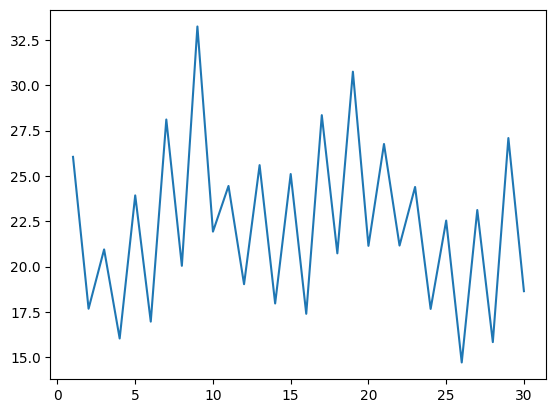

In [449]:
s = list(t)
# area under temperature
a=[]
for k in range(0,len(s),h_w):
    a.append(area(s[k:k+h_w])/h_w)
x = np.array(range(1,len(a)+1))
plt.plot(x,a)

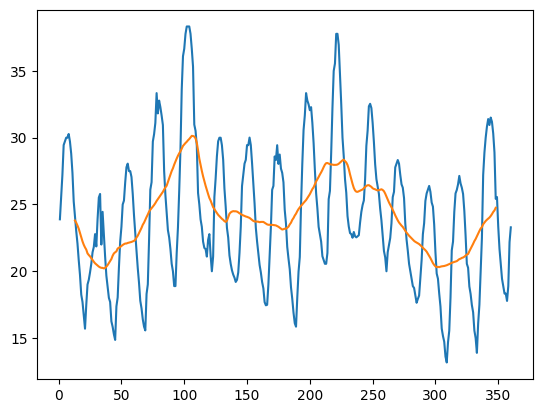

In [450]:
x = np.array(range(1,len(t)+1))
area(t)

plt.plot(x,t)
plt.plot(x[h_w:len(x)-h_w],mean_days)

(1.9500000000000002, [<matplotlib.lines.Line2D at 0x22a8b7dccd0>])

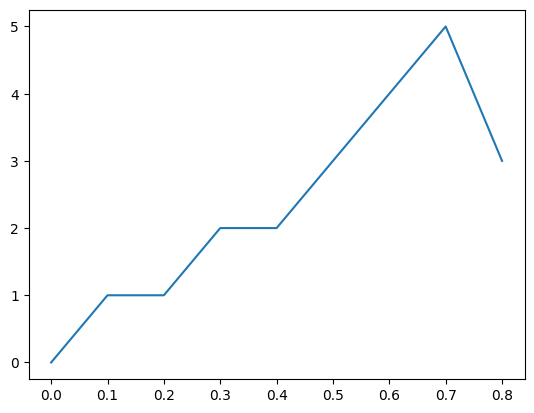

In [451]:
df = [0,1,1,2,2,3,4,5,3]
dx = .1
x = np.array(range(len(df)))
area(df,dx),plt.plot(x*dx,df)


(-0.35000000000000003, [<matplotlib.lines.Line2D at 0x22a8b671950>])

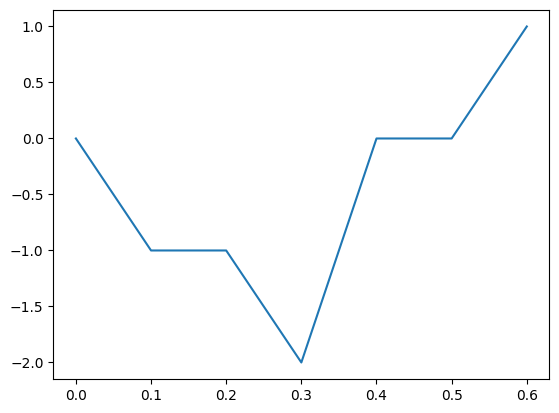

In [452]:
# valeurs négatives
dx = 0.1
df = [0,-1,-1,-2,0,0,1]
x = np.array(range(len(df)))
area(df,dx),plt.plot(x*dx,df)

In [453]:
n = data.tail(1)['dates'].values[0]
n, type(n)

('09/08/26 10:00:00', str)

In [454]:
def days_hours_minutes(td):
    return td.days, td.seconds//3600, (td.seconds//60)%60

In [455]:
savefig = False
ref = '07/08/25 07:00:00'
datetime_object = datetime.strptime(ref, '%d/%m/%y %H:%M:%S')
datetime_object

datetime.datetime(2025, 8, 7, 7, 0)

In [456]:
def get_next_save_date(ref_date, current_date=None):
    global savefig
    """
    Calculate the next save date (every 7 days from reference date).
    
    Args:
        ref_date (datetime): The reference start date
        current_date (datetime, optional): Date to check from. Defaults to now.
    
    Returns:
        savefig : update flag
        datetime: Next save date
    """
    if current_date is None:
        current_date = datetime.now()
    
    delta = current_date - ref_date
    days_since_last_save = delta.days % 7
    print(days_since_last_save)
    if days_since_last_save == 0:
        print("Save the figure")
        savefig = True
        return current_date
    else:
        return current_date + dt.timedelta(days=(7 - days_since_last_save))


In [457]:
# Example usage
next_save = get_next_save_date(datetime_object)
print(savefig)
print(f"Next save will be on: {next_save.strftime('%d/%m/%y')}")
td = datetime.now() - datetime_object
if savefig:
    print("Save figure")
else:
    print("No saving today")

3
False
Next save will be on: 13/08/26
No saving today


In [458]:
ref, td, td.days%7, days_hours_minutes(td)

('07/08/25 07:00:00',
 datetime.timedelta(days=367, seconds=12095, microseconds=210032),
 3,
 (367, 3, 21))

In [459]:
end = time.time()
print(end - begin)

21.762409687042236


In [460]:
savefig

False

In [461]:
data.tail(15)  # 02/01/2026 22h index 14918 à recopier vers temp02012026.csv

,temp,hours,dates,variation,heures,jours
20143,30.31,20673.833333,08/08/26 20:00:00,-0.87,20,08/08/26
20144,28.88,20673.875000,08/08/26 21:00:00,-1.43,21,08/08/26
20145,25.41,20673.916667,08/08/26 22:00:00,-3.47,22,08/08/26
20146,25.55,20673.958333,08/08/26 23:00:00,0.14,23,08/08/26
20147,23.32,20674.000000,09/08/26 00:00:00,-2.23,00,09/08/26
20148,21.66,20674.041667,09/08/26 01:00:00,-1.66,01,09/08/26
20149,20.55,20674.083333,09/08/26 02:00:00,-1.11,02,09/08/26
20150,19.43,20674.125000,09/08/26 03:00:00,-1.12,03,09/08/26
20151,18.88,20674.166667,09/08/26 04:00:00,-0.55,04,09/08/26
20152,18.32,20674.208333,09/08/26 05:00:00,-0.56,05,09/08/26


# Température depuis 15 jours par heure

In [462]:
today = datetime.now()
today_str = today.strftime('%d/%m/%y %H:%M:%S')

In [463]:
data.tail(1)["dates"].values[0].split(':')[0], today_str.split(':')[0]


('09/08/26 10', '09/08/26 10')

### test de validité de data !

#### vérification de ligne de données manquantes

In [464]:
difference_heures = int(data.tail(1)["dates"].values[0].split(' ')[1].split(':')[0]) - int(today_str.split(' ')[1].split(':')[0])   
difference_heures

0

In [465]:
assert data.tail(1)["dates"].values[0].split(':')[0] == today_str.split(':')[0]

In [466]:
jours = 15

In [467]:
# liste des températures sur une même plage horaire de 24h des 7 derniers jours
data_24_list = [list([data.tail(24*t).temp.head(24).values]) for t in range(jours, 0, -1)]
data_24_list

[[array([23.88, 25.55, 27.21, 29.44, 29.71, 29.99, 29.99, 30.27, 29.71,
         28.8 , 27.36, 25.22, 24.11, 23.  , 22.07, 20.82, 19.71, 18.24,
         17.69, 16.66, 15.69, 17.48, 19.  , 19.35])],
 [array([19.91, 20.55, 21.41, 21.81, 22.77, 21.85, 23.89, 25.51, 25.78,
         21.99, 24.44, 22.77, 21.1 , 19.66, 18.8 , 18.  , 17.69, 16.24,
         15.83, 15.27, 14.85, 17.36, 18.03, 20.26])],
 [array([22.21, 23.32, 24.99, 25.28, 26.65, 27.78, 28.05, 27.49, 27.49,
         27.05, 25.78, 24.19, 22.91, 21.52, 20.22, 19.12, 17.78, 17.21,
         16.39, 15.84, 15.56, 18.29, 19.01, 22.34])],
 [array([26.1 , 26.66, 29.7 , 30.26, 31.1 , 33.33, 31.81, 32.77, 32.28,
         31.65, 30.94, 27.49, 25.71, 24.43, 23.07, 22.53, 21.66, 20.55,
         19.99, 18.88, 18.88, 21.36, 23.28, 26.01])],
 [array([29.14, 33.59, 36.09, 36.65, 37.76, 38.32, 38.32, 38.32, 37.77,
         36.66, 35.31, 30.97, 30.51, 29.39, 25.85, 25.  , 23.88, 23.32,
         22.21, 21.74, 21.65, 21.09, 22.34, 22.77])],
 [array([2

### moyenne sur la même plage de 24h sur ...

In [468]:
print(jours, 'jours')

15 jours


In [469]:
# Add all arrays element-wise
sum_array = np.sum(data_24_list, axis=0)

# Divide by jours to get mean
mean_array = sum_array / jours

print("Sum array:", sum_array)
print("Mean array:", mean_array)

Sum array: [[355.82 385.04 407.76 428.56 442.84 452.11 453.51 453.6  446.21 430.39
  415.58 382.02 362.86 344.96 326.62 313.72 300.75 288.87 280.05 270.96
  264.61 283.36 303.92 327.24]]
Mean array: [[23.72133333 25.66933333 27.184      28.57066667 29.52266667 30.14066667
  30.234      30.24       29.74733333 28.69266667 27.70533333 25.468
  24.19066667 22.99733333 21.77466667 20.91466667 20.05       19.258
  18.67       18.064      17.64066667 18.89066667 20.26133333 21.816     ]]


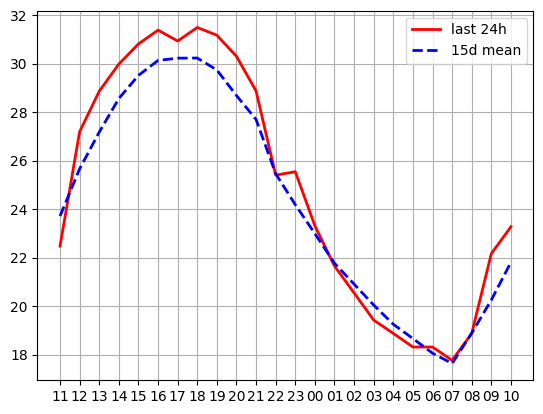

In [470]:
lw = 1
all = False
for t in range(jours,0,-1):
    #if t==1: lw=4
    if t==1:
        plt.plot(data.tail(24*t).heures.head(24),data.tail(24*t).temp.head(24),lw=lw+1,label='last 24h',c='red')
        plt.plot(range(24),mean_array[0],lw=lw+1,label='15d mean',c='blue',ls='--')
    elif all:
        plt.plot(range(24),data_24_list[t-1][0],lw=lw,label=-t)
plt.legend()
plt.grid()

### courbes de températures journalières superposées 
### 15 jours


In [471]:
jours

15

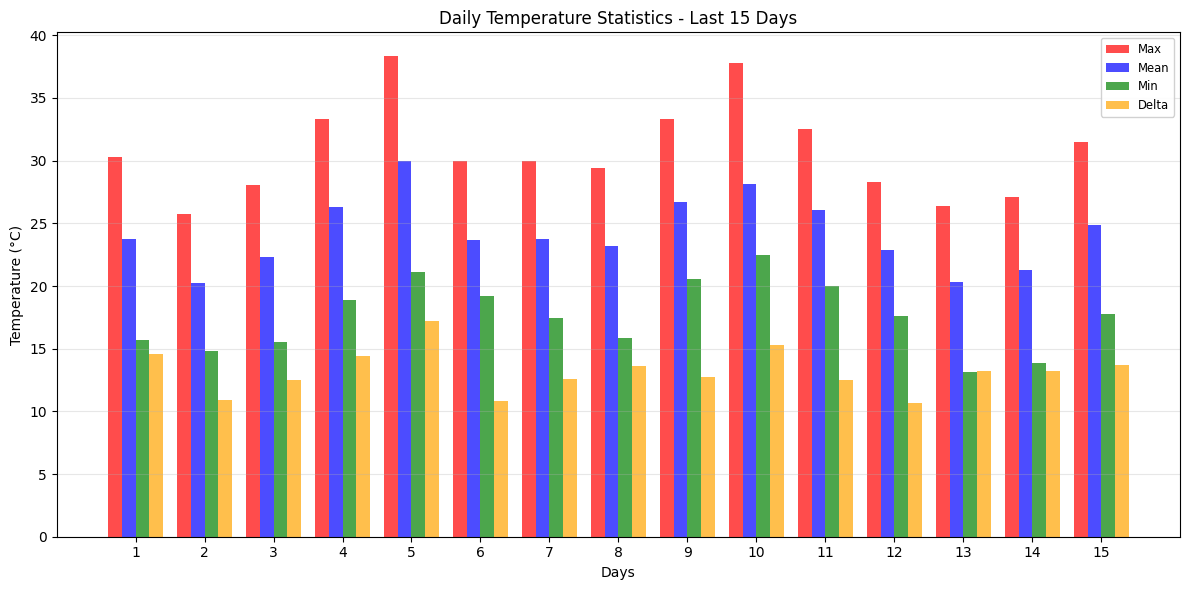

In [472]:
# Create a summary dataframe with daily statistics
df1 = pd.DataFrame({
    'high': [data.tail(24*t).temp.head(24).max() for t in range(jours, 0, -1)],
    'low': [data.tail(24*t).temp.head(24).min() for t in range(jours, 0, -1)],
    'moy': [data.tail(24*t).temp.head(24).mean() for t in range(jours, 0, -1)],
    'delta': [data.tail(24*t).temp.head(24).max() - data.tail(24*t).temp.head(24).min() for t in range(jours, 0, -1)]
})

# Plot the daily statistics
fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(df1))
width = 0.2

ax.bar(x_pos - width*1.5, df1['high'], width, label='Max', color='red', alpha=0.7)
ax.bar(x_pos - width/2, df1['moy'], width, label='Mean', color='blue', alpha=0.7)
ax.bar(x_pos + width/2, df1['low'], width, label='Min', color='green', alpha=0.7)
ax.bar(x_pos + width*1.5, df1['delta'], width, label='Delta', color='orange', alpha=0.7)

ax.set_xlabel('Days')
ax.set_ylabel('Temperature (°C)')
ax.set_title(f'Daily Temperature Statistics - Last {jours} Days')
ax.set_xticks(x_pos)
ax.set_xticklabels(range(1, len(df1)+1))
ax.legend()
ax.legend(fontsize='small', loc='best', framealpha=0.9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 15 days temperature

Next save date: 13/08/2026 10:21


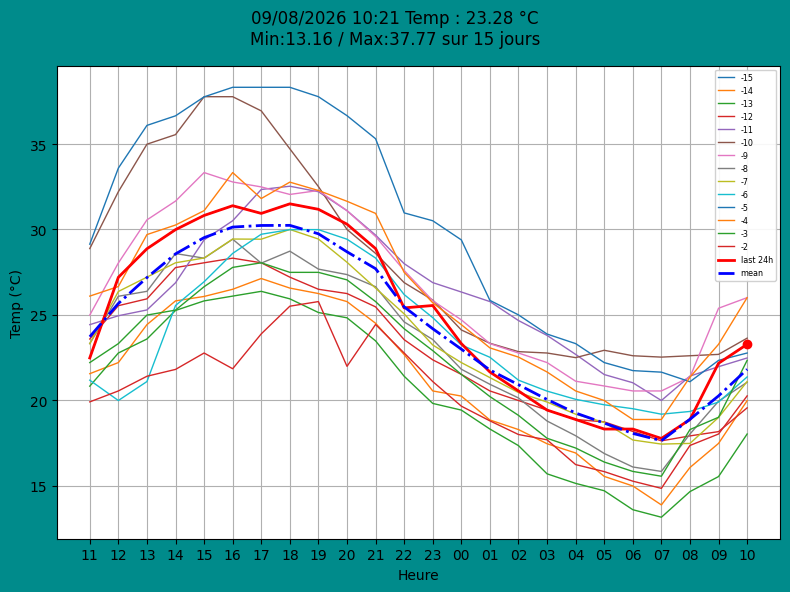

In [473]:
fig, ax = plt.subplots(figsize=(8, 6),facecolor='darkcyan')
#lw = 1
datetime_object = datetime.now()
for t in range(jours,0,-1):
    #if t==1: lw=4
    x = data.tail(24*t).heures.head(24)
    if t==1:
        plt.plot(x,data.tail(24*t).temp.head(24),lw=lw+1,label='last 24h',c='red')
        #plt.plot(x,data_24_list[t-1][0],lw=lw+1,label=-t,c='red')
        plt.plot(x,mean_array[0],lw=lw+1,label='mean',c='blue',ls='-.')
    else:
        #plt.plot(x,data.tail(24*t).temp.head(24),lw=lw,label=-t)
        plt.plot(x,data_24_list[t-1][0],lw=lw,label=-t)

plt.plot(data.tail(1).heures,data.tail(1).temp,'ro')
fig.suptitle(f"{datetime_object.strftime('%d/%m/%Y %H:%M')} Temp : {round(data.tail(1).temp.values[0],2)} °C\nMin:{_min_} / Max:{_max_} sur {jours} jours")
plt.xlabel(f"Heure")
plt.ylabel("Temp (°C)")
plt.grid()
# Valid font size are xx-small, x-small, small, medium, large, x-large, xx-large, larger, smaller, None
plt.legend(fontsize='xx-small', loc='best', framealpha=0.9)

#savefig = True
# save figure if needed
if savefig:
    fig_filename = next_save.strftime('%Y%m%d') + '_7daystemp.png'
    plt.savefig(fig_filename)
    print('Fig saved')
else:
    print('Next save date:', next_save.strftime('%d/%m/%Y %H:%M'))

plt.tight_layout()
plt.show()

In [474]:
data['temp'].tail(24*jours).describe()

count    360.000000
mean      24.226000
std        5.289749
min       13.160000
25%       20.200000
50%       23.555000
75%       27.835000
max       38.320000
Name: temp, dtype: float64

<Axes: ylabel='Density'>

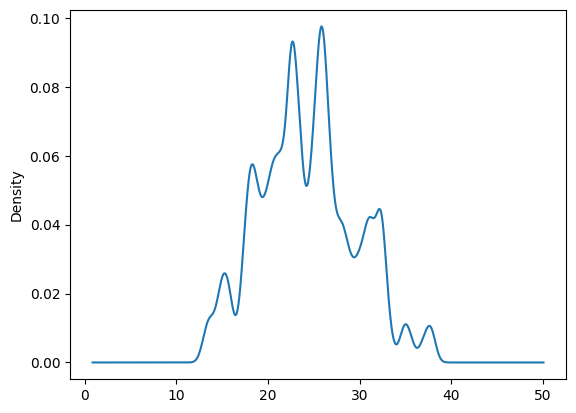

In [475]:
_7days = data['temp'].tail(24*7)
#_7days.hist(bins=20, width=0.5, alpha=0.7)
_7days.plot.kde(bw_method=0.1)


<Axes: >

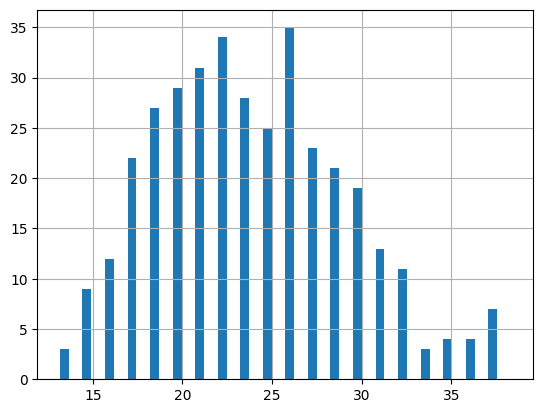

In [476]:
_7days = data['temp'].tail(24*jours)
_7days.hist(bins=20,width=0.5)

In [477]:
print('Min:', _7days.min(), ', Max:', _7days.max(), ', Mean:', _7days.mean())

Min: 13.160000000000023 , Max: 38.32000000000005 , Mean: 24.22600000000002


In [478]:
t=7
max_, min_ = np.max(list(data.tail(24*t).temp.head(24))), np.min(list(data.tail(24*t).temp.head(24)))
print(max_,min_)

33.33000000000004 20.55000000000001


In [479]:
df_jours=data.tail(24*7)
df

[0, -1, -1, -2, 0, 0, 1]

In [480]:
df_jours.groupby('jours')['temp'].mean()

jours
02/08/26    30.176923
03/08/26    27.980417
04/08/26    26.115833
05/08/26    24.595417
06/08/26    21.747500
07/08/26    20.654583
08/08/26    23.510000
09/08/26    20.234545
Name: temp, dtype: float64

<Axes: xlabel='jours'>

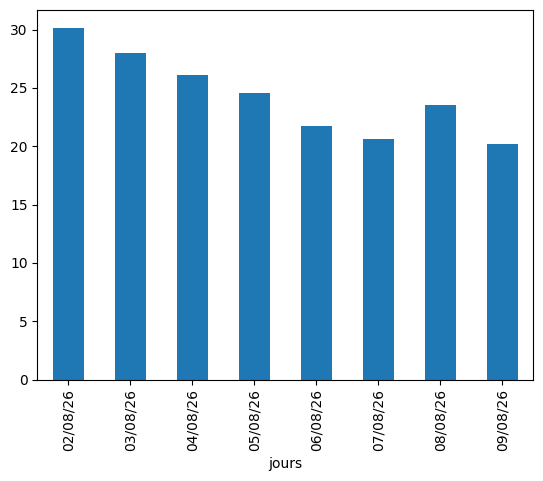

In [481]:
df_jours.groupby('jours')['temp'].mean().plot(kind='bar')

In [482]:
csv_file1

'Y:\\Documents\\temp03062024.csv'

# Save to CSV

In [483]:
save = False
# save to csv 
if save : 
    if csv_file1 == r"Y:\Documents\temp03062024.csv":
        csv_file = r"../data_temp03062024.csv"  
    else:
        csv_file = r"../data_temp02012026.csv"  # 02/01/2026 22h
    to_csv(csv_file, data)

In [484]:
# how to stop here

class StopExecution(Exception):
    def _render_traceback_(self):
        return []
#raise StopExecution

#raise
#assert(False)
#raise KeyboardInterrupt
#ext  # create an error

import this
#dir(list)
#dir(str)

# how to label on top of a bar plot

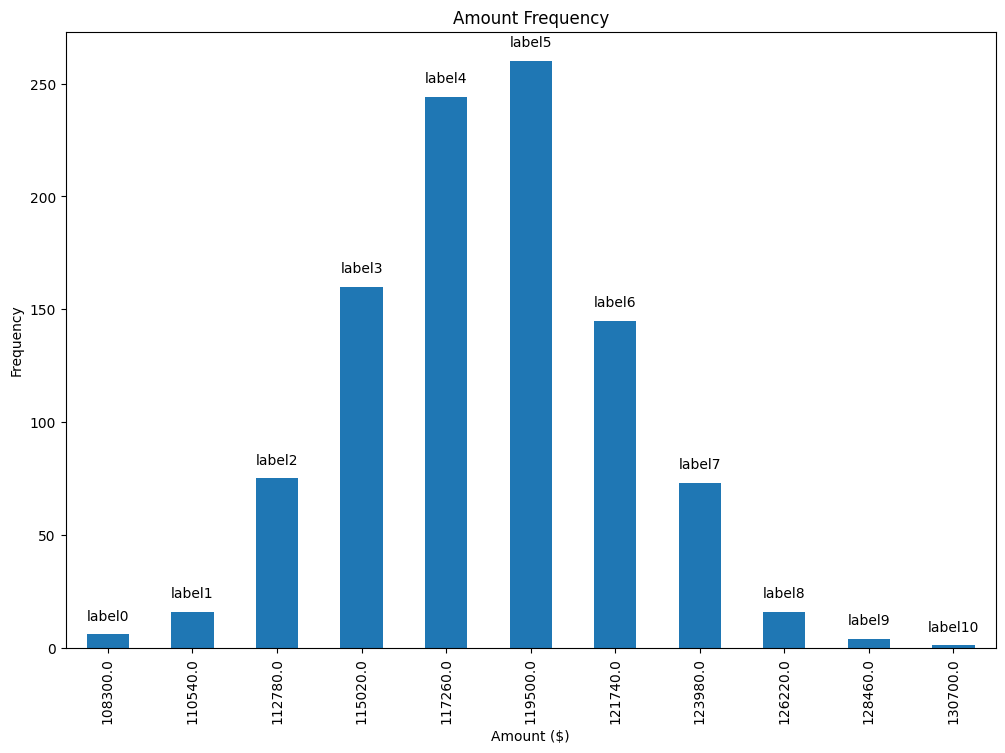

In [485]:
# Bring some raw data.
frequencies = [6, 16, 75, 160, 244, 260, 145, 73, 16, 4, 1]
# In my original code I create a series and run on that,
# so for consistency I create a series from the list.
freq_series = pd.Series(frequencies)

x_labels = [
    108300.0,
    110540.0,
    112780.0,
    115020.0,
    117260.0,
    119500.0,
    121740.0,
    123980.0,
    126220.0,
    128460.0,
    130700.0,
]

# Plot the figure.
plt.figure(figsize=(12, 8))
ax = freq_series.plot(kind="bar")
ax.set_title("Amount Frequency")
ax.set_xlabel("Amount ($)")
ax.set_ylabel("Frequency")
ax.set_xticklabels(x_labels)

rects = ax.patches

# Make some labels.
labels = [f"label{i}" for i in range(len(rects))]

for rect, label in zip(rects, labels):
    height = rect.get_height()
    ax.text(
        rect.get_x() + rect.get_width() / 2, height + 5, label, ha="center", va="bottom"
    )

plt.show()

In [486]:
areas = []
moys = []
x = []
for t in range(jours,0,-1):
    x.append(-t)
    a = area(data.tail(24*t+1).temp.head(25))    # calcul sur 24h
    areas.append(round(a/24,2))
    moys.append(round(data.tail(24*t+1).temp.head(25).mean(),2))
    #print(-t,a)
#print(areas,x)
len(data.tail(24*t+1)),moys

(25,
 [np.float64(23.66),
  np.float64(20.2),
  np.float64(22.27),
  np.float64(26.11),
  np.float64(29.79),
  np.float64(23.65),
  np.float64(23.62),
  np.float64(23.09),
  np.float64(26.49),
  np.float64(28.05),
  np.float64(25.98),
  np.float64(22.87),
  np.float64(20.26),
  np.float64(21.11),
  np.float64(24.68)])

In [487]:
data

,temp,hours,dates,variation,heures,jours
0,13.19,19834.541667,21/04/24 13:00:00,NaN,13,21/04/24
1,12.20,19834.583333,21/04/24 14:00:00,-0.99,14,21/04/24
2,12.29,19834.625000,21/04/24 15:00:00,0.09,15,21/04/24
3,12.42,19834.666667,21/04/24 16:00:00,0.13,16,21/04/24
4,14.54,19834.708333,21/04/24 17:00:00,2.12,17,21/04/24
...,...,...,...,...,...,...
20153,18.32,20674.250000,09/08/26 06:00:00,0.00,06,09/08/26
20154,17.77,20674.291667,09/08/26 07:00:00,-0.55,07,09/08/26
20155,18.88,20674.333333,09/08/26 08:00:00,1.11,08,09/08/26
20156,22.17,20674.375000,09/08/26 09:00:00,3.29,09,09/08/26


In [488]:
areas


[23.81,
 20.22,
 22.31,
 26.19,
 30.01,
 23.71,
 23.72,
 23.18,
 26.61,
 28.19,
 26.1,
 22.94,
 20.32,
 21.2,
 24.81]

[Text(-8.0, 0, '-7'),
 Text(-6.0, 0, '-6'),
 Text(-4.0, 0, '-5'),
 Text(-2.0, 0, '-4'),
 Text(0.0, 0, '-3'),
 Text(2.0, 0, '-2'),
 Text(4.0, 0, '-1'),
 Text(6.0, 0, '0'),
 Text(8.0, 0, '1')]

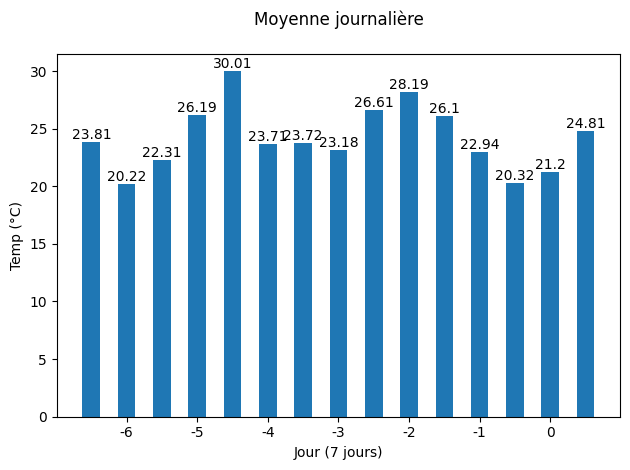

In [489]:
X_axis = np.arange(len(x))-7
fig, ax = plt.subplots()
plt.title("Moyenne journalière\n")
plt.xlabel("Jour (7 jours)")
plt.ylabel("Temp (°C)")
#plt.plot(x,areas,"r")
plt.bar(X_axis,areas,width=0.5)
fig.tight_layout()
# plt.bar(X_axis-0.3,areas,width=0.1)
# plt.bar(X_axis+0.3,moys,width=0.1)
rects = ax.patches

# Make some labels.
labels = [rects[i].get_height() for i in range(len(rects))]

for rect, label in zip(rects, labels):
    height = rect.get_height()
    offset = sign(label)*0.1-0.1
    ax.text(
        rect.get_x() + rect.get_width() / 2, height + offset, label, ha="center", va="bottom"
    )
ax.set_xticklabels(X_axis)


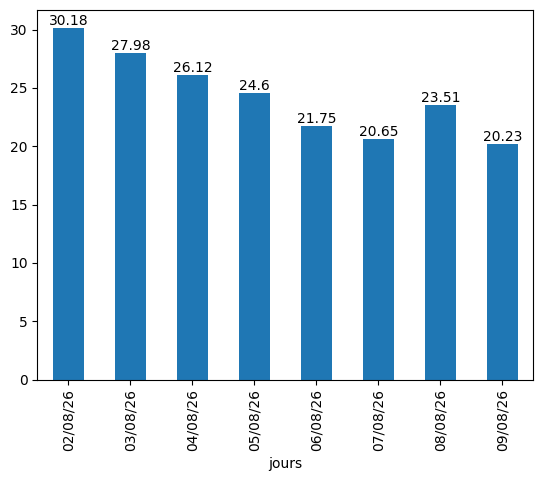

In [490]:
fig, ax = plt.subplots()
df_jours.groupby('jours')['temp'].mean().plot(kind='bar')
rects = ax.patches

# Make some labels.
labels = [round(rects[i].get_height(),2) for i in range(len(rects))]

for rect, label in zip(rects, labels):
    height = rect.get_height()
    offset = sign(label)*0.1-0.1
    ax.text(
        rect.get_x() + rect.get_width() / 2, height + offset, label, ha="center", va="bottom"
    )


In [491]:
labels

[np.float64(30.18),
 np.float64(27.98),
 np.float64(26.12),
 np.float64(24.6),
 np.float64(21.75),
 np.float64(20.65),
 np.float64(23.51),
 np.float64(20.23)]

In [492]:
df = list(data.tail(24).temp.head(24))
df,area(df)

([22.48000000000001,
  27.200000000000045,
  28.870000000000005,
  29.99000000000001,
  30.82000000000005,
  31.390000000000043,
  30.94,
  31.5,
  31.180000000000007,
  30.31,
  28.879999999999995,
  25.410000000000025,
  25.55000000000001,
  23.32000000000005,
  21.660000000000025,
  20.55000000000001,
  19.430000000000007,
  18.879999999999995,
  18.32000000000005,
  18.32000000000005,
  17.77000000000004,
  18.879999999999995,
  22.170000000000016,
  23.28000000000003],
 574.2200000000005)

In [493]:
moy = []
for i in range(len(df)-1):
    moy.append((df[i]+df[i+1])/2)
sum(moy)

574.2200000000005

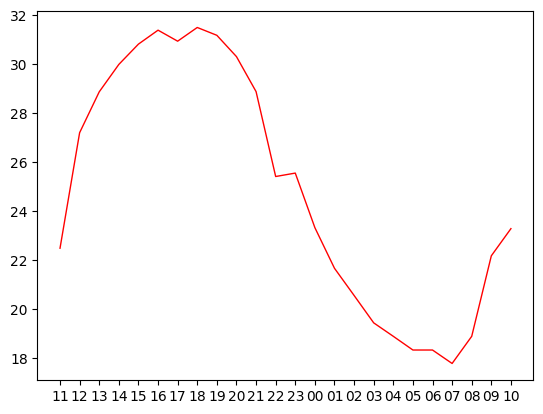

In [494]:
plt.plot(data.tail(24).heures.head(24),data.tail(24).temp.head(24),lw=lw,label=-t,c='red')

In [495]:
data.tail()


,temp,hours,dates,variation,heures,jours
20153,18.32,20674.250000,09/08/26 06:00:00,0.00,06,09/08/26
20154,17.77,20674.291667,09/08/26 07:00:00,-0.55,07,09/08/26
20155,18.88,20674.333333,09/08/26 08:00:00,1.11,08,09/08/26
20156,22.17,20674.375000,09/08/26 09:00:00,3.29,09,09/08/26
20157,23.28,20674.416667,09/08/26 10:00:00,1.11,10,09/08/26


In [496]:
chop = data.tail(24).temp
_max, _min = local_min_max(list(chop))
_max,_min,len(_max),len(_min)

([31.390000000000043, 31.5, 25.55000000000001],
 [22.48000000000001, 30.94, 25.410000000000025, 17.77000000000004],
 3,
 4)

In [497]:
_diff=[M-m for M,m in zip(_max, _min)]

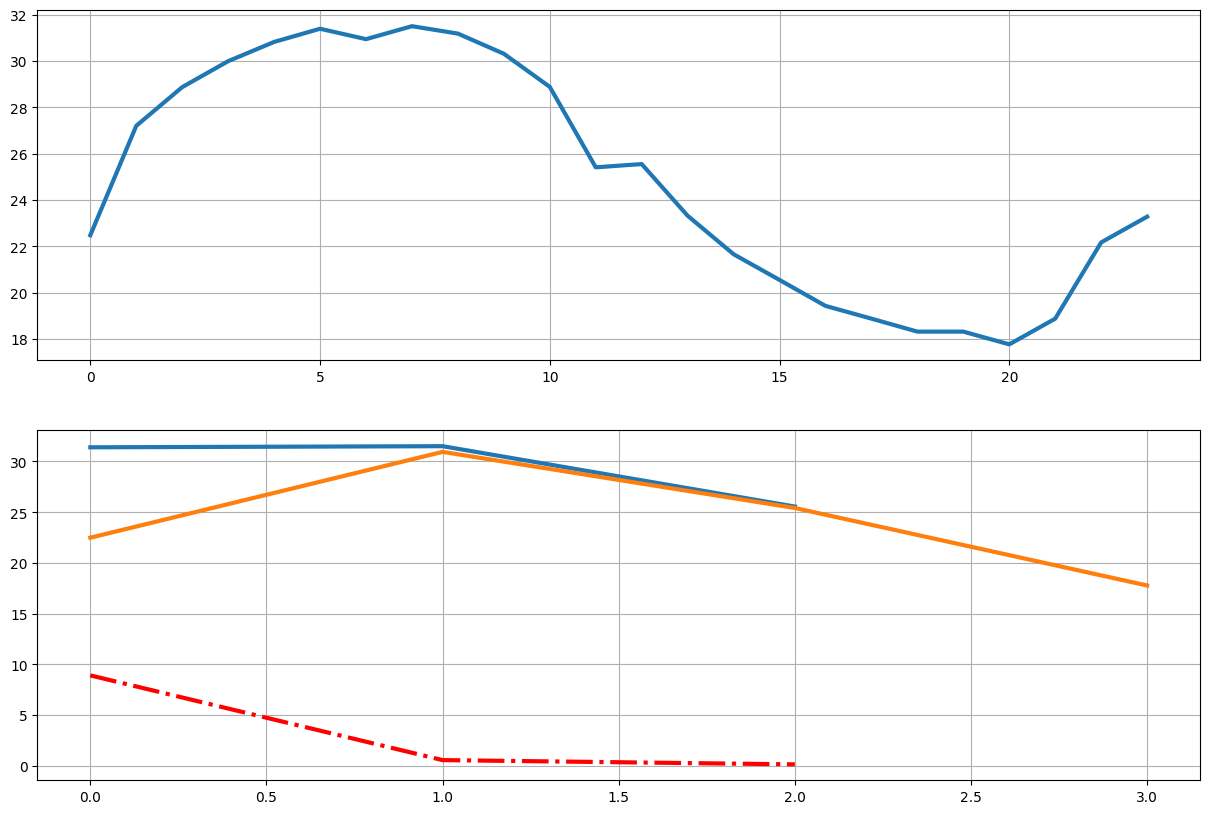

In [498]:
fig, (ax1,ax2) = plt.subplots(2,1)
# the size of A4 paper
fig.set_size_inches(15, 10)
ax1.plot(list(data.tail(24).temp),lw=3)
ax1.grid()
ax2.plot(_max,lw=3)
ax2.plot(_min,lw=3)
ax2.plot(_diff,'r-.',lw=3)
ax2.grid()

[] 0 [1] 1
[] 0 [1] 1


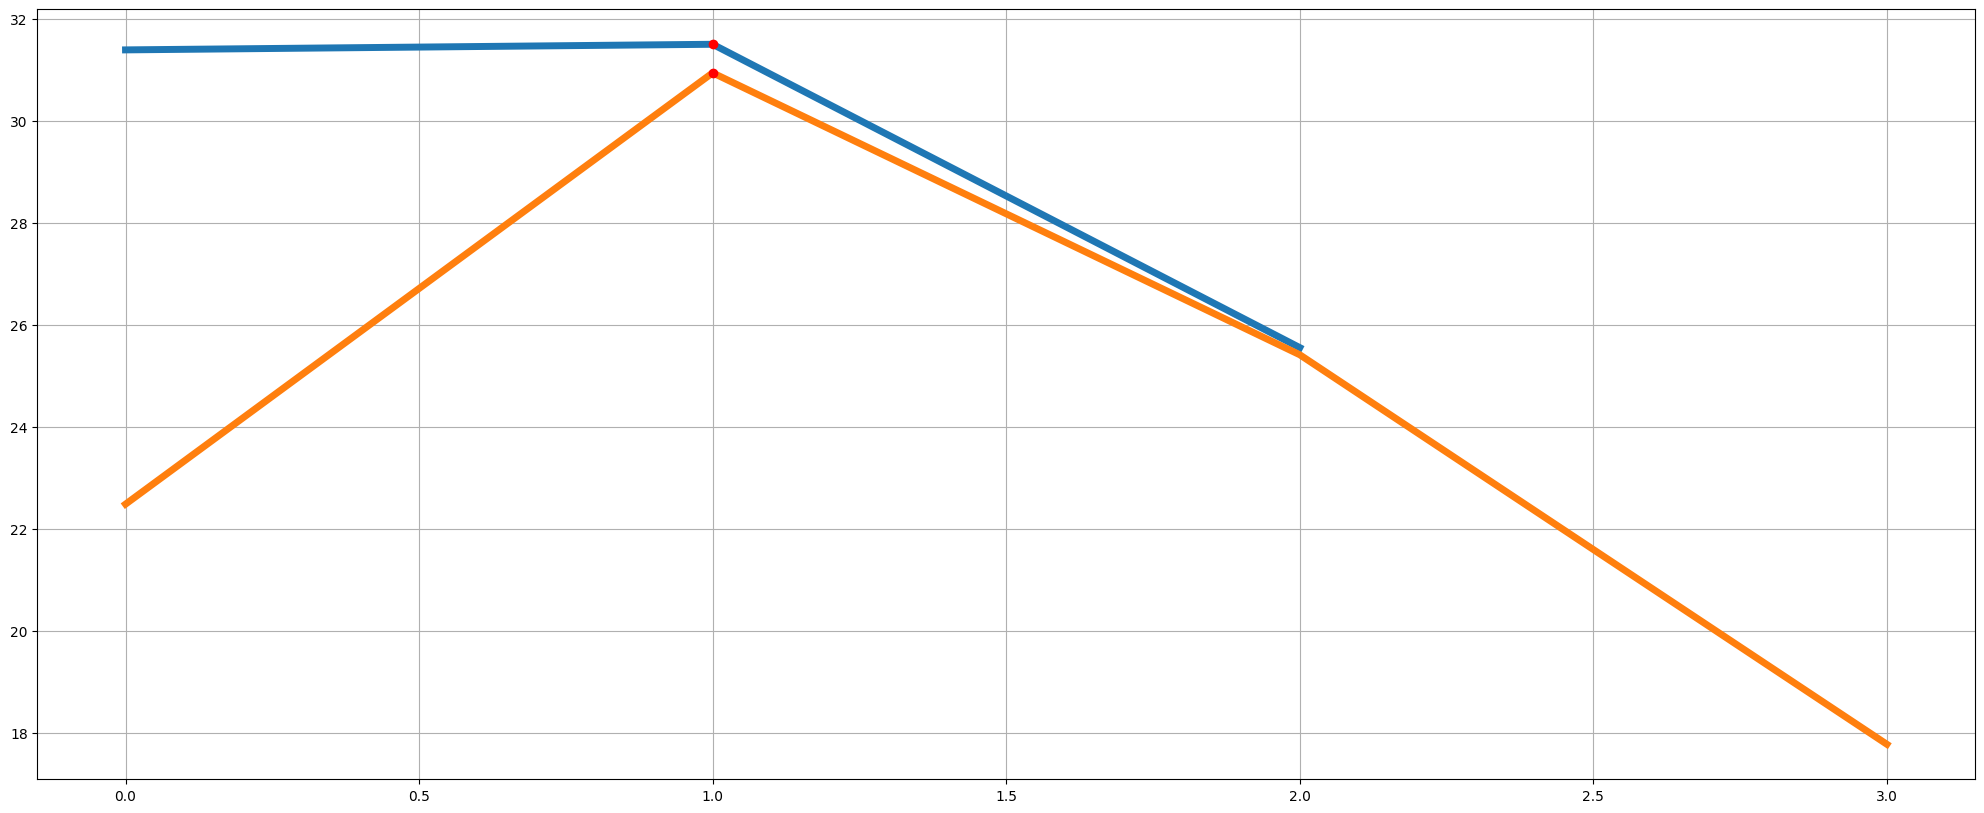

In [499]:
fig, ax = plt.subplots()
# the size of A4 paper
fig.set_size_inches(25, 10)
x =  range(len(_max))
plot_data(x,_max,lw=5)
x =  range(len(_min))
plot_data(x,_min,lw=5)
plt.grid()

In [500]:
liste = [10, 11, 15, 12, 9, 7, 8, 10, 13, 15, 18, 16, 12, 10, 7, 5, 6, 11, 14, 14]
diff(liste)


array([ 1,  4, -3, -3, -2,  1,  2,  3,  2,  3, -2, -4, -2, -3, -2,  1,  5,
        3,  0])

In [501]:
sign(diff(liste))


array([ 1,  1, -1, -1, -1,  1,  1,  1,  1,  1, -1, -1, -1, -1, -1,  1,  1,
        1,  0])

In [502]:
diff(sign(diff(liste)))


array([ 0, -2,  0,  0,  2,  0,  0,  0,  0, -2,  0,  0,  0,  0,  2,  0,  0,
       -1])

In [503]:
diff(sign(diff(liste)))>0


array([False, False, False, False,  True, False, False, False, False,
       False, False, False, False, False,  True, False, False, False])

In [504]:
(diff(sign(diff(liste)))).nonzero()

(array([ 1,  4,  9, 14, 17]),)

# maximas, minimas

[ 5 15] 2 [ 2 10 18] 3


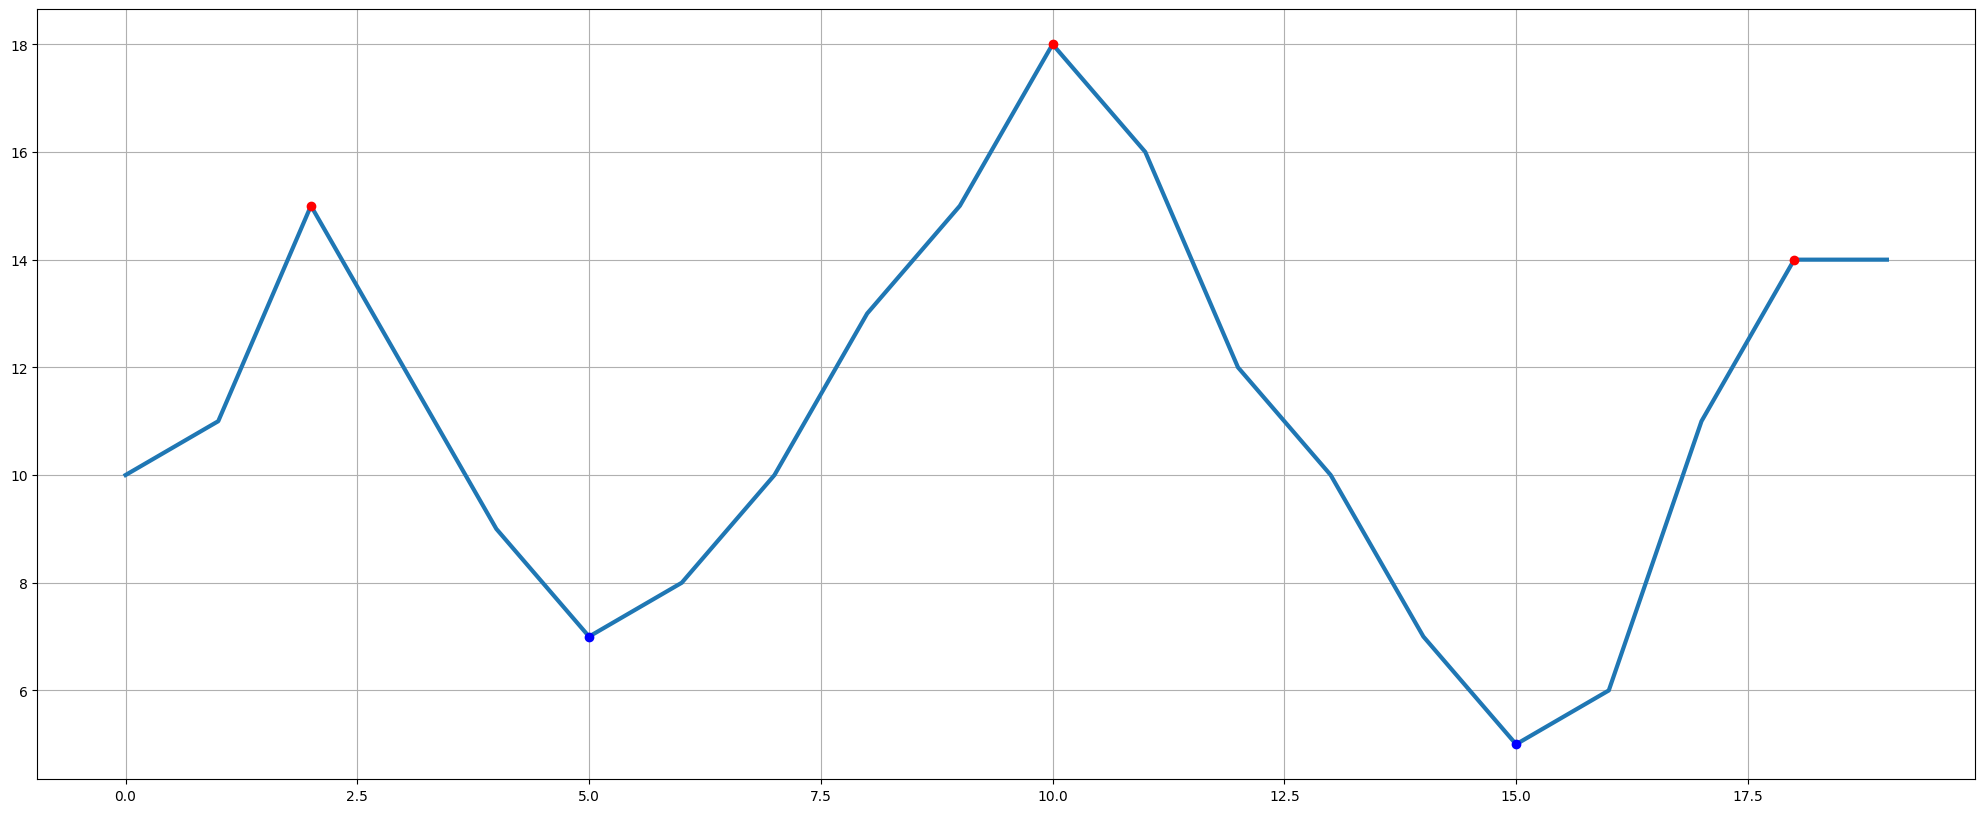

In [505]:
fig, ax = plt.subplots()
# the size of A4 paper
fig.set_size_inches(25, 10)
x = range(len(liste))
_data = liste
plot_data(x, _data)


In [506]:
date_time_str,days,interval

('21/04/24 13:00:00', 15, 12)

In [507]:
df

[22.48000000000001,
 27.200000000000045,
 28.870000000000005,
 29.99000000000001,
 30.82000000000005,
 31.390000000000043,
 30.94,
 31.5,
 31.180000000000007,
 30.31,
 28.879999999999995,
 25.410000000000025,
 25.55000000000001,
 23.32000000000005,
 21.660000000000025,
 20.55000000000001,
 19.430000000000007,
 18.879999999999995,
 18.32000000000005,
 18.32000000000005,
 17.77000000000004,
 18.879999999999995,
 22.170000000000016,
 23.28000000000003]

## last records

In [508]:
# 7 jours temp, mean
df = pd.DataFrame(data.tail(7*24)['temp'])
df['mean']= mean_days[-7*24:]
df

,temp,mean
19990,24.99,23.175833
19991,28.04,23.245417
19992,30.56,23.326667
19993,31.66,23.500833
19994,33.33,23.628750
...,...,...
20153,18.32,24.128333
20154,17.77,24.267083
20155,18.88,24.429167
20156,22.17,24.546250


# temperature, moyenne, variation

<Axes: >

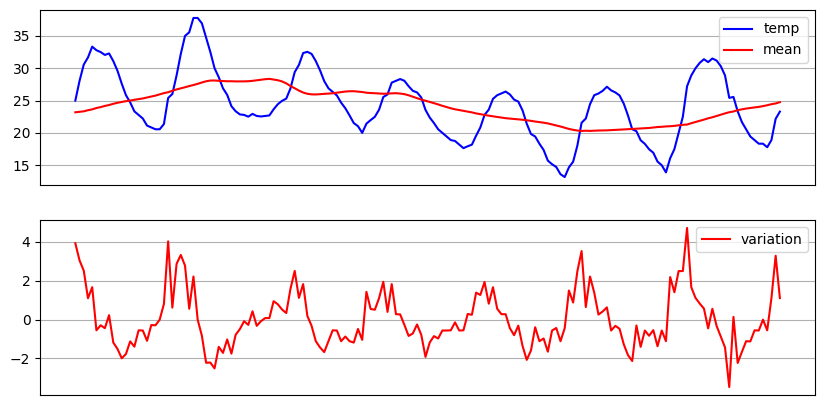

In [509]:
fig, axes = plt.subplots(nrows=2, ncols=1)

# plot temp, mean
df.plot(ax=axes[0],figsize=(10,5),color=['blue','red'],grid=True, legend=True,rot=45,xticks=[])
# 7 jours variation
data.tail(7*24)['variation'].plot(ax=axes[1],figsize=(10,5),color='red',grid=True, legend=True,rot=45,xticks=[])

In [510]:
data.tail(24*7)['temp'].max(),data.tail(24*7)['temp'].min()

(np.float64(37.77000000000004), np.float64(13.160000000000023))

In [511]:
def high_low(n):
    # variation 24 heures il y a n jours
    #n = 0
    l = len(data)
    e = n*24
    s = e+24

    high = round(data[l-s:l-e]['temp'].max(),2)
    low = round(data[l-s:l-e]['temp'].min(),2)
    delta = round(high - low,2)
    return high,low,delta

In [512]:
# max, min, delta sur n jours
n = 30
high_n = []
low_n = []
moy_n =  []
delta_n = []
for k in range(n):
    h,l,d = high_low(n-1-k)
    high_n.append(h)
    low_n.append(l)
    moy_n.append((h+l)/2)
    delta_n.append(d)
    print('J',-(n-1-k),h,l,d)


J -29 35.28 20.83 14.45
J -28 36.11 20.83 15.28
J -27 35.55 22.13 13.42
J -26 34.71 21.18 13.53
J -25 34.71 23.24 11.47
J -24 32.22 20.78 11.44
J -23 33.61 18.96 14.65
J -22 29.34 17.22 12.12
J -21 30.27 14.35 15.92
J -20 24.5 13.6 10.9
J -19 23.89 13.79 10.1
J -18 25.7 14.82 10.88
J -17 25.56 14.75 10.81
J -16 24.66 14.43 10.23
J -15 28.05 16.66 11.39
J -14 30.27 15.69 14.58
J -13 25.78 14.85 10.93
J -12 28.05 15.56 12.49
J -11 33.33 18.88 14.45
J -10 38.32 21.09 17.23
J -9 29.99 19.19 10.8
J -8 30.0 17.44 12.56
J -7 29.43 15.84 13.59
J -6 33.33 20.55 12.78
J -5 37.77 22.5 15.27
J -4 32.53 19.99 12.54
J -3 28.32 17.63 10.69
J -2 26.38 13.16 13.22
J -1 27.13 13.88 13.25
J 0 31.5 17.77 13.73


<Axes: >

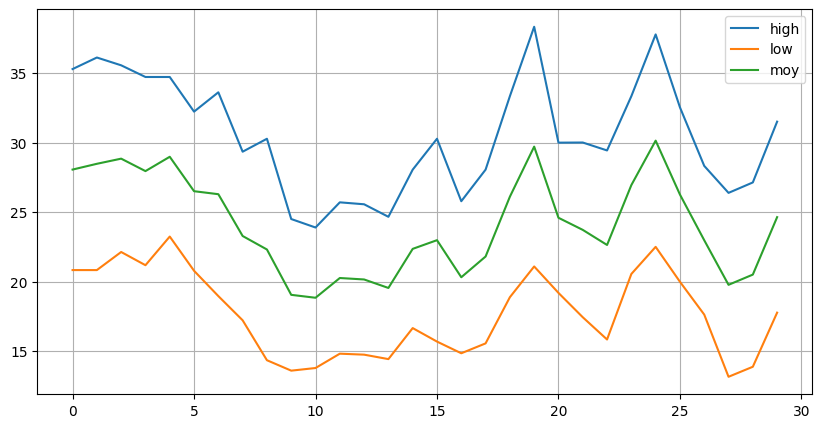

In [513]:
# pandas plot
df1 = pd.DataFrame()
df1['high'] = high_n
df1['low'] = low_n
df1['moy'] = moy_n
df1['delta'] = delta_n
df1[['high','low','moy']].plot(figsize=(10,5),grid=True, legend=True)

In [514]:
_data = list(df1['high'])
_max, _min = local_min_max(_data)
_max


[36.11, 33.61, 30.27, 25.7, 30.27, 38.32, 30.0, 37.77]

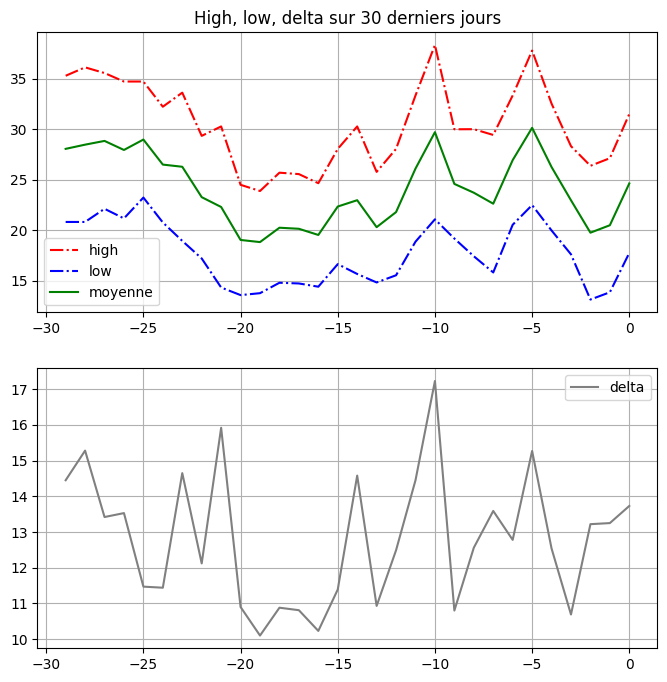

In [515]:
# plot lists
x = range(-29,1,1)
fig, (ax1, ax2) = plt.subplots(2,1)
# the size of A4 paper
fig.set_size_inches(8, 8)
ax1.set_title('High, low, delta sur '+str(n)+' derniers jours')
ax1.plot(x,high_n, '-.',color='red',label='high')
ax1.plot(x,low_n, '-.', color='blue',label = 'low')
ax1.plot(x,moy_n, color='green',label = 'moyenne')
ax1.grid()
ax1.legend()
#moy_n = [(h+l)/2 for h,l in zip(high_n,low_n)]

ax2.plot(x,delta_n,color='grey',label='delta')
ax2.grid()
ax2.legend()

In [516]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20158 entries, 0 to 20157
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   temp       20158 non-null  float64
 1   hours      20158 non-null  float64
 2   dates      20158 non-null  object 
 3   variation  20157 non-null  float64
 4   heures     20158 non-null  object 
 5   jours      20158 non-null  object 
dtypes: float64(3), object(3)
memory usage: 945.0+ KB


In [517]:
data_24 = data.tail(25)[['hours','dates','variation']]
#len(data_24),data_24


In [518]:
# plot X_axis
date_24 = np.array(data.tail(25)['hours'])
#date_24

In [519]:
# inutile ! il faut utiliser le champ data.hours
def mk_date2(data):
    str1, str2 = data_24.head(1)['dates'].values[0] , data_24.tail(1)['dates'].values[0] 
    print(str1,str2)
    return mdates.drange(datetime.strptime(str1, '%d/%m/%y %H:%M:%S'),datetime.strptime(str2, '%d/%m/%y %H:%M:%S'),dt.timedelta(hours=1))
#date_24 = mk_date2(data_24)

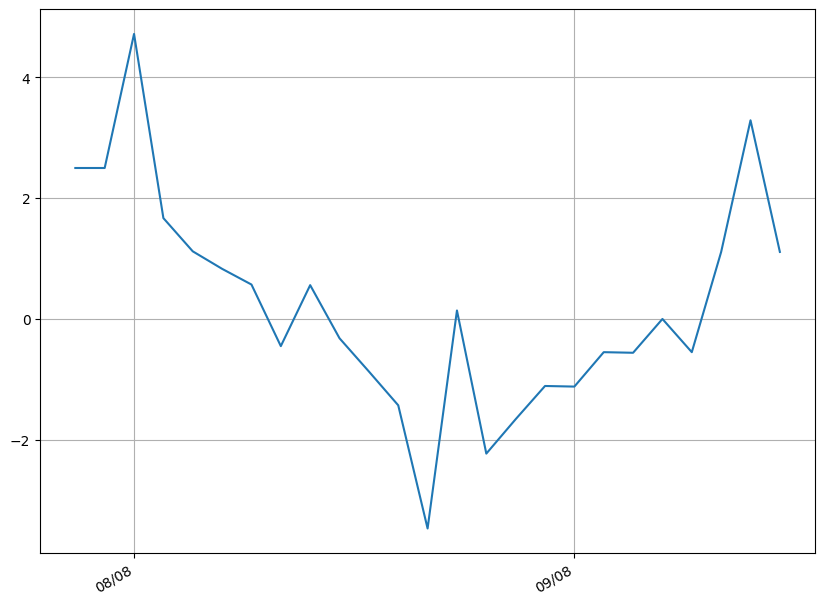

In [520]:
l = len(date_24)
data.tail(l)[['temp','variation']]
var = data.tail(l)[['variation']].values

fig, ax = plt.subplots()
fig.set_size_inches(10, 8)
plt.plot(date_24,var)
format_date()
#plt.grid()

In [521]:
w = int(24*days)
days,data.tail(w)['temp'].max(), data.tail(w)['temp'].min()


(15, np.float64(38.32000000000005), np.float64(13.160000000000023))

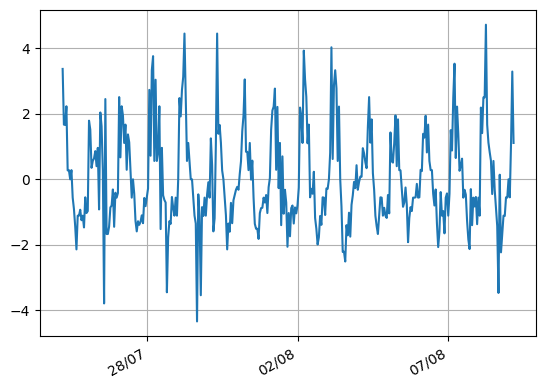

In [522]:
#data['variation'].tail(w).plot()
plt.plot(data['hours'].tail(w),data['variation'].tail(w))
format_date(24)

### date pour les temp max, min

In [523]:
d_max = data.tail(w)['temp'].max()
d_max, data[data['temp']==data.tail(w)['temp'].max()]['dates']

(np.float64(38.32000000000005),
 19899    29/07/26 16:00:00
 19900    29/07/26 17:00:00
 19901    29/07/26 18:00:00
 Name: dates, dtype: object)

In [524]:
d_min = data.tail(w)['temp'].min()
d_min, data[data['temp']==data.tail(w)['temp'].min()]['dates']

(np.float64(13.160000000000023),
 552      14/05/24 13:00:00
 3590     18/09/24 03:00:00
 4712     03/11/24 21:00:00
 9426     19/05/25 07:00:00
 17228    09/04/26 09:00:00
 17444    18/04/26 09:00:00
 20106    07/08/26 07:00:00
 Name: dates, dtype: object)

In [525]:
data.tail(w)['temp'].describe()

count    360.000000
mean      24.226000
std        5.289749
min       13.160000
25%       20.200000
50%       23.555000
75%       27.835000
max       38.320000
Name: temp, dtype: float64

In [526]:
from  datetime import datetime
#matplotlib.dates.date2num(hours)
#then.isoformat(),round(temp[-1],2)
today = datetime.now()




In [527]:
data.tail(1)["dates"].values[0].split(':')[0]


'09/08/26 10'

In [528]:
# current date and time
ts = datetime.timestamp(today)
ts

1786263712.269329